# March Machine Learning Mania 2026 — Exploratory Data Analysis

## Competition Overview
Predict the probability that one team beats another in the 2026 NCAA Division I Men's and Women's basketball tournaments.

**Evaluation:** Brier Score (equivalent to Mean Squared Error for binary outcomes)
$$\text{Brier Score} = \frac{1}{N} \sum_{i=1}^{N} (p_i - o_i)^2$$
where $p_i$ is the predicted probability and $o_i \in \{0, 1\}$ is the actual outcome.


---

## Table of Contents
1. [Setup & Data Loading](#1)
2. [Data Overview](#2)
3. [Tournament Structure](#3)
4. [Score Analysis](#4)
5. [Team Performance](#5)
6. [Box Score (Detailed Stats) Analysis](#6)
7. [Seed Analysis](#7)
8. [Conference Analysis](#8)
9. [Rankings Analysis (Massey Ordinals)](#9)
10. [Men's vs Women's Comparison](#10)
11. [Temporal Trends](#11)
12. [Feature Engineering Ideas & Summary](#12)

<a id='1'></a>
## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.stats import spearmanr
import warnings
import os

# warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid', palette='deep', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

DATA_DIR = './data/'
print('Setup complete.')

Setup complete.


In [2]:
# Load all CSV files
datasets = {}
for f in sorted(os.listdir(DATA_DIR)):
    if f.endswith('.csv'):
        key = f.replace('.csv', '')
        datasets[key] = pd.read_csv(os.path.join(DATA_DIR, f))
        print(f"{key:45s} {str(datasets[key].shape):>15s}")

print(f"\nTotal datasets loaded: {len(datasets)}")

Cities                                               (509, 3)
Conferences                                           (51, 2)
MConferenceTourneyGames                             (6793, 5)
MGameCities                                        (91940, 6)
MMasseyOrdinals_part_1                           (2909614, 5)
MMasseyOrdinals_part_2                           (2909614, 5)
MNCAATourneyCompactResults                          (2585, 8)
MNCAATourneyDetailedResults                        (1449, 34)
MNCAATourneySeedRoundSlots                           (776, 5)
MNCAATourneySeeds                                   (2626, 3)
MNCAATourneySlots                                   (2586, 4)
MRegularSeasonCompactResults                      (198079, 8)
MRegularSeasonDetailedResults                    (124031, 34)
MSeasons                                              (42, 6)
MSecondaryTourneyCompactResults                     (1865, 9)
MSecondaryTourneyTeams                              (1895, 3)
MTeamCoa

In [3]:
# Shorthand references
m_teams = datasets['MTeams']
w_teams = datasets['WTeams']
m_rs_compact = datasets['MRegularSeasonCompactResults']
w_rs_compact = datasets['WRegularSeasonCompactResults']
m_rs_detail = datasets['MRegularSeasonDetailedResults']
w_rs_detail = datasets['WRegularSeasonDetailedResults']
m_tourney_compact = datasets['MNCAATourneyCompactResults']
w_tourney_compact = datasets['WNCAATourneyCompactResults']
m_tourney_detail = datasets['MNCAATourneyDetailedResults']
w_tourney_detail = datasets['WNCAATourneyDetailedResults']
m_seeds = datasets['MNCAATourneySeeds'].copy()
w_seeds = datasets['WNCAATourneySeeds'].copy()
massey_1 = datasets['MMasseyOrdinals_part_1']
massey_2 = datasets['MMasseyOrdinals_part_2']
massey = pd.concat([massey_1,massey_2])
m_conferences = datasets['MTeamConferences']
w_conferences = datasets['WTeamConferences']
conferences = datasets['Conferences']
m_coaches = datasets['MTeamCoaches']
m_slots = datasets['MNCAATourneySlots']
w_slots = datasets['WNCAATourneySlots']
m_seasons = datasets['MSeasons']
w_seasons = datasets['WSeasons']
cities = datasets['Cities']
m_game_cities = datasets['MGameCities']
w_game_cities = datasets['WGameCities']
sub_stage1 = datasets['SampleSubmissionStage1']
sub_stage2 = datasets['SampleSubmissionStage2']

datasets["MMasseyOrdinals"] = massey

print('References created.')

References created.


<a id='2'></a>
## 2. Data Overview

In [4]:
# Summary table of all datasets
summary_rows = []
for name, df in datasets.items():
    season_range = ''
    if 'Season' in df.columns:
        season_range = f"{df['Season'].min()}-{df['Season'].max()}"
    missing = df.isnull().sum().sum()
    summary_rows.append({
        'Dataset': name,
        'Rows': f"{len(df):,}",
        'Columns': len(df.columns),
        'Column Names': ', '.join(df.columns[:6]) + ('...' if len(df.columns) > 6 else ''),
        'Missing Values': missing,
        'Season Range': season_range
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.style.set_properties(**{'text-align': 'left'}).set_table_styles(
    [{'selector': 'th', 'props': [('text-align', 'left')]}]
)

,Dataset,Rows,Columns,Column Names,Missing Values,Season Range
0,Cities,509,3,"CityID, City, State",0,
1,Conferences,51,2,"ConfAbbrev, Description",0,
2,MConferenceTourneyGames,"6,793",5,"Season, ConfAbbrev, DayNum, WTeamID, LTeamID",0,2001-2025
3,MGameCities,"91,940",6,"Season, DayNum, WTeamID, LTeamID, CRType, CityID",0,2010-2026
4,MMasseyOrdinals_part_1,"2,909,614",5,"Season, RankingDayNum, SystemName, TeamID, OrdinalRank",0,2003-2017
5,MMasseyOrdinals_part_2,"2,909,614",5,"Season, RankingDayNum, SystemName, TeamID, OrdinalRank",0,2017-2026
6,MNCAATourneyCompactResults,"2,585",8,"Season, DayNum, WTeamID, WScore, LTeamID, LScore...",0,1985-2025
7,MNCAATourneyDetailedResults,"1,449",34,"Season, DayNum, WTeamID, WScore, LTeamID, LScore...",0,2003-2025
8,MNCAATourneySeedRoundSlots,776,5,"Seed, GameRound, GameSlot, EarlyDayNum, LateDayNum",0,
9,MNCAATourneySeeds,"2,626",3,"Season, Seed, TeamID",0,1985-2025


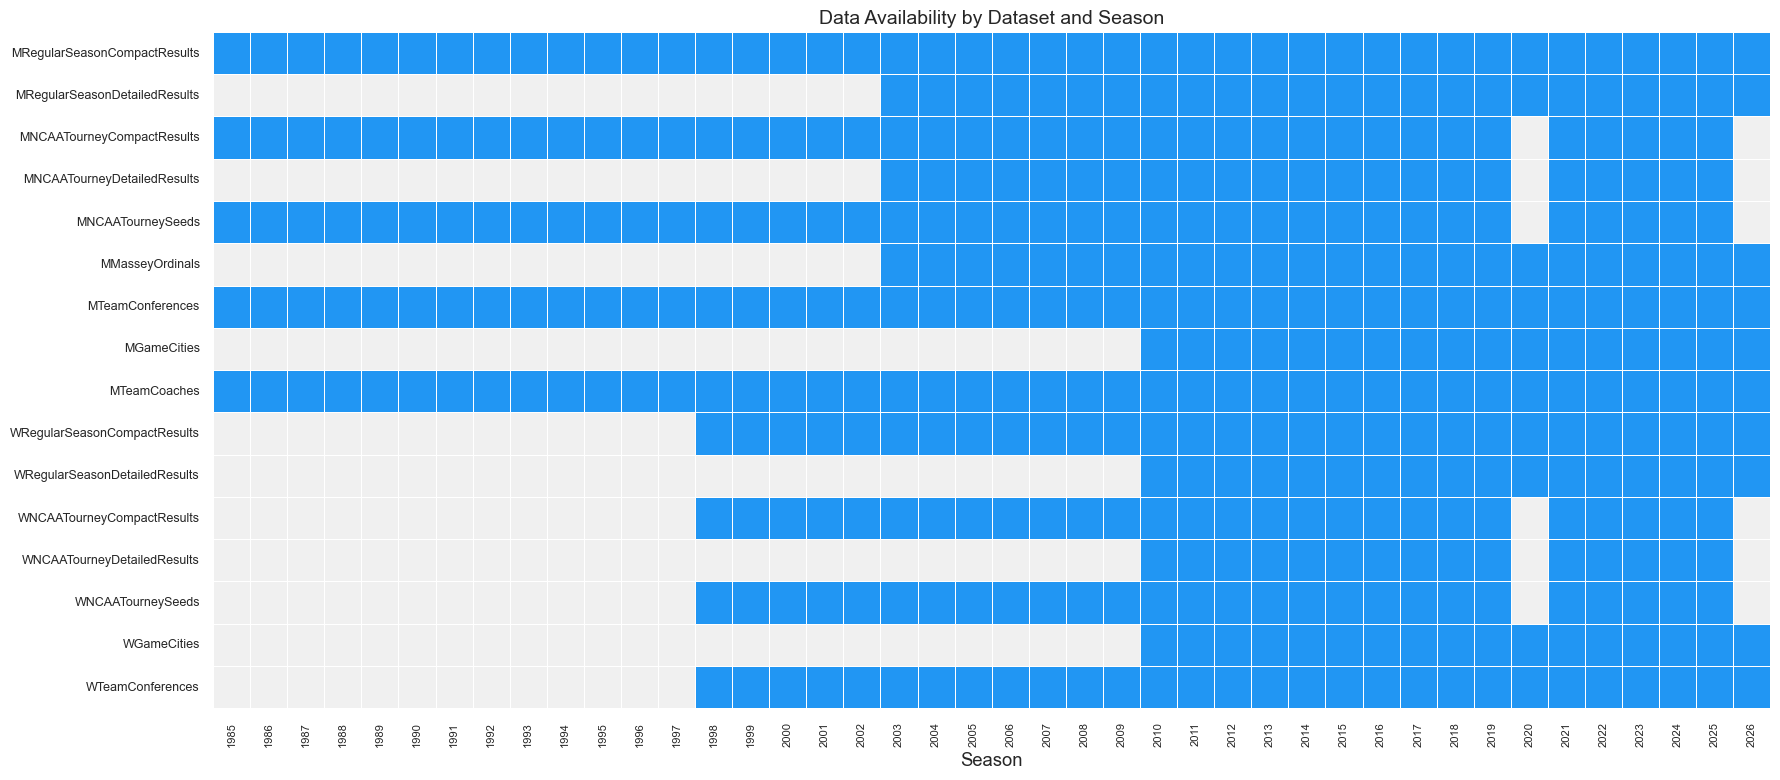

In [5]:
# Data availability timeline heatmap
availability = {}
key_datasets = [
    'MRegularSeasonCompactResults', 'MRegularSeasonDetailedResults',
    'MNCAATourneyCompactResults', 'MNCAATourneyDetailedResults',
    'MNCAATourneySeeds', 'MMasseyOrdinals',
    'MTeamConferences', 'MGameCities', 'MTeamCoaches',
    'WRegularSeasonCompactResults', 'WRegularSeasonDetailedResults',
    'WNCAATourneyCompactResults', 'WNCAATourneyDetailedResults',
    'WNCAATourneySeeds', 'WGameCities', 'WTeamConferences'
]
all_seasons = list(range(1985, 2027))

for ds_name in key_datasets:
    df = datasets[ds_name]
    if 'Season' in df.columns:
        seasons_present = set(df['Season'].unique())
        availability[ds_name] = [1 if s in seasons_present else 0 for s in all_seasons]

avail_df = pd.DataFrame(availability, index=all_seasons).T

fig, ax = plt.subplots(figsize=(18, 8))
sns.heatmap(avail_df, cmap=['#f0f0f0', '#2196F3'], cbar=False, linewidths=0.5,
            xticklabels=all_seasons, yticklabels=True, ax=ax)
ax.set_xlabel('Season')
ax.set_title('Data Availability by Dataset and Season', fontsize=14)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

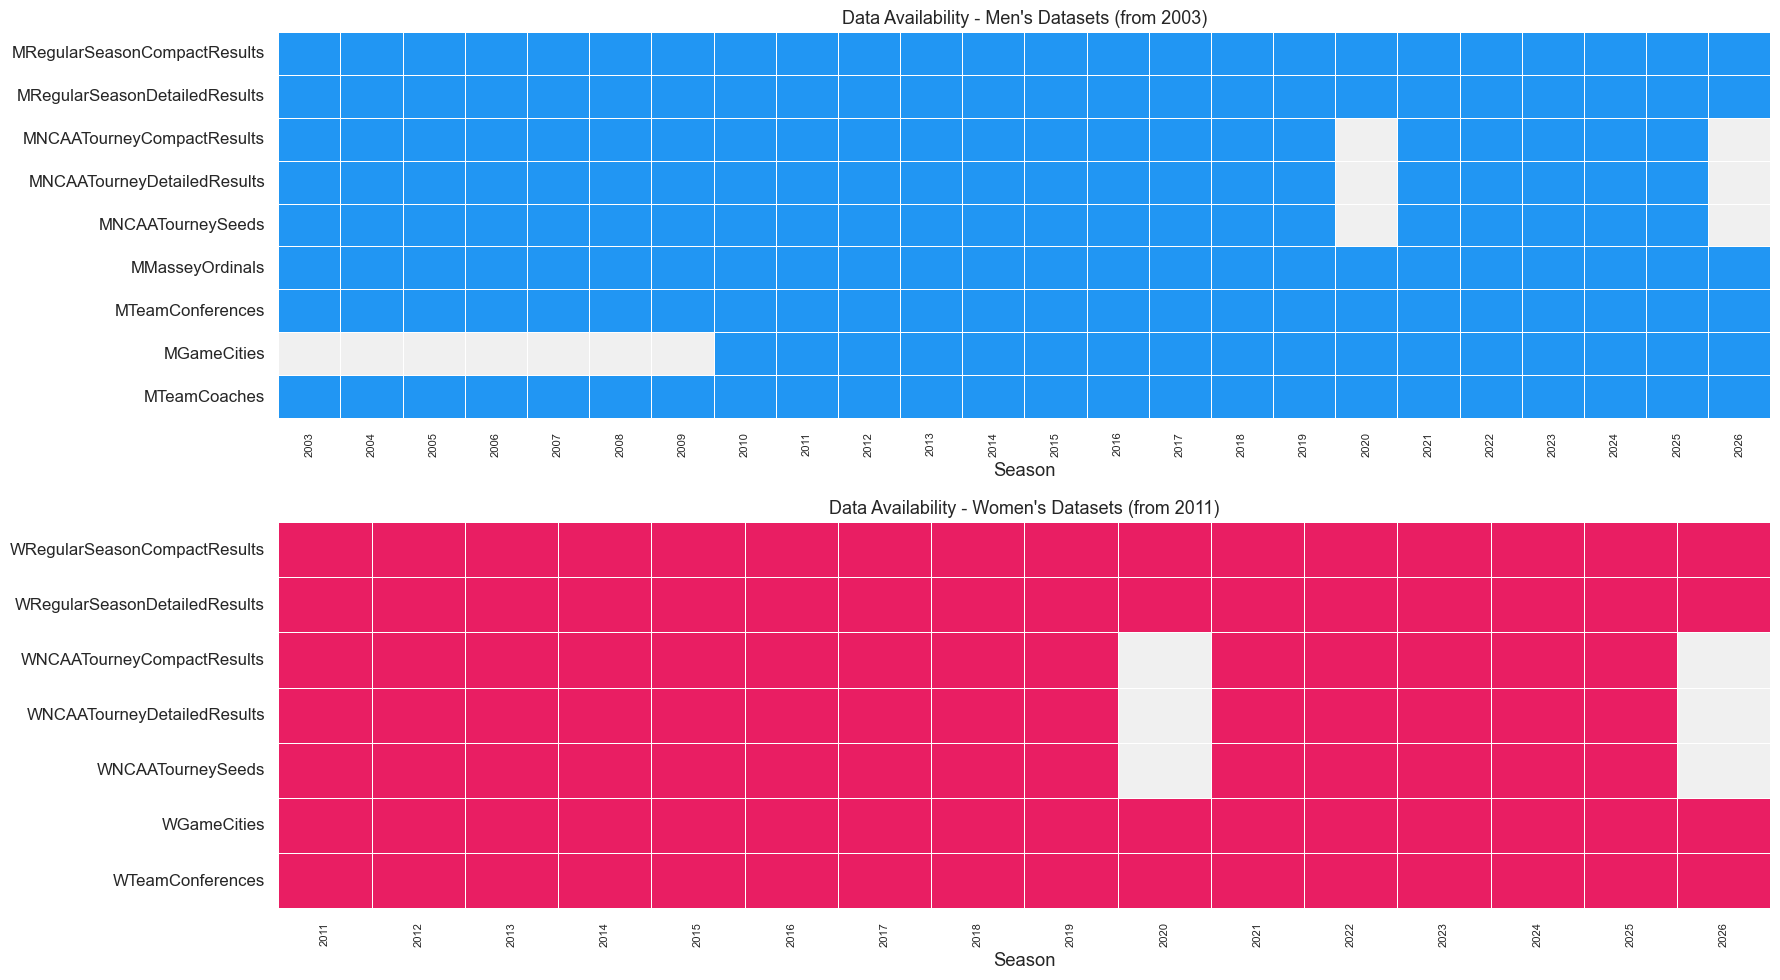

In [6]:
# Data availability heatmap - filtered: mens datasets from 2003, womens from 2011
m_datasets = [
    "MRegularSeasonCompactResults", "MRegularSeasonDetailedResults",
    "MNCAATourneyCompactResults", "MNCAATourneyDetailedResults",
    "MNCAATourneySeeds", "MMasseyOrdinals",
    "MTeamConferences", "MGameCities", "MTeamCoaches"
]
w_datasets = [
    "WRegularSeasonCompactResults", "WRegularSeasonDetailedResults",
    "WNCAATourneyCompactResults", "WNCAATourneyDetailedResults",
    "WNCAATourneySeeds", "WGameCities", "WTeamConferences"
]

availability_filtered = {}
m_seasons = list(range(2003, 2027))
w_seasons = list(range(2011, 2027))

for ds_name in m_datasets:
    df = datasets[ds_name]
    if "Season" in df.columns:
        seasons_present = set(df["Season"].unique())
        availability_filtered[ds_name] = [1 if s in seasons_present else 0 for s in m_seasons + [None] * len(w_seasons)]

# Build separate dataframes and combine
avail_m = {}
for ds_name in m_datasets:
    df = datasets[ds_name]
    if "Season" in df.columns:
        seasons_present = set(df["Season"].unique())
        avail_m[ds_name] = [1 if s in seasons_present else 0 for s in m_seasons]

avail_w = {}
for ds_name in w_datasets:
    df = datasets[ds_name]
    if "Season" in df.columns:
        seasons_present = set(df["Season"].unique())
        avail_w[ds_name] = [1 if s in seasons_present else 0 for s in w_seasons]

avail_m_df = pd.DataFrame(avail_m, index=m_seasons).T
avail_w_df = pd.DataFrame(avail_w, index=w_seasons).T

fig, axes = plt.subplots(2, 1, figsize=(18, 10))

sns.heatmap(avail_m_df, cmap=["#f0f0f0", "#2196F3"], cbar=False, linewidths=0.5,
            xticklabels=m_seasons, yticklabels=True, ax=axes[0])
axes[0].set_xlabel("Season")
axes[0].set_title("Data Availability - Men's Datasets (from 2003)", fontsize=13)
plt.setp(axes[0].get_xticklabels(), rotation=90, fontsize=8)

sns.heatmap(avail_w_df, cmap=["#f0f0f0", "#E91E63"], cbar=False, linewidths=0.5,
            xticklabels=w_seasons, yticklabels=True, ax=axes[1])
axes[1].set_xlabel("Season")
axes[1].set_title("Data Availability - Women's Datasets (from 2011)", fontsize=13)
plt.setp(axes[1].get_xticklabels(), rotation=90, fontsize=8)

plt.tight_layout()
plt.show()

── Filter: Men >= 2003, Women >= 2011 ──────────────────────────────────────

In [7]:

M_FROM = 2003
W_FROM = 2011

m_rs_compact      = m_rs_compact[m_rs_compact["Season"] >= M_FROM]
w_rs_compact      = w_rs_compact[w_rs_compact["Season"] >= W_FROM]
m_rs_detail       = m_rs_detail[m_rs_detail["Season"] >= M_FROM]
w_rs_detail       = w_rs_detail[w_rs_detail["Season"] >= W_FROM]
m_tourney_compact = m_tourney_compact[m_tourney_compact["Season"] >= M_FROM]
w_tourney_compact = w_tourney_compact[w_tourney_compact["Season"] >= W_FROM]
m_tourney_detail  = m_tourney_detail[m_tourney_detail["Season"] >= M_FROM]
w_tourney_detail  = w_tourney_detail[w_tourney_detail["Season"] >= W_FROM]
m_seeds           = m_seeds[m_seeds["Season"] >= M_FROM]
w_seeds           = w_seeds[w_seeds["Season"] >= W_FROM]
massey            = massey[massey["Season"] >= M_FROM]
m_conferences     = m_conferences[m_conferences["Season"] >= M_FROM]
w_conferences     = w_conferences[w_conferences["Season"] >= W_FROM]
m_coaches         = m_coaches[m_coaches["Season"] >= M_FROM]
m_game_cities     = m_game_cities[m_game_cities["Season"] >= M_FROM]
w_game_cities     = w_game_cities[w_game_cities["Season"] >= W_FROM]

print(f"Men data: seasons {m_rs_compact['Season'].min()}–{m_rs_compact['Season'].max()}")
print(f"Women data: seasons {w_rs_compact['Season'].min()}–{w_rs_compact['Season'].max()}")

Men data: seasons 2003–2026
Women data: seasons 2011–2026


In [8]:
# Submission format analysis
print('=== Stage 1 Submission (Historical Validation) ===')
print(f'Shape: {sub_stage1.shape}')
print(f'Sample IDs: {sub_stage1["ID"].head(3).tolist()}')

# Parse IDs
s1_parsed = sub_stage1['ID'].str.split('_', expand=True)
s1_parsed.columns = ['Season', 'TeamID1', 'TeamID2']
s1_parsed = s1_parsed.astype(int)

print(f'Seasons: {sorted(s1_parsed["Season"].unique())}')
print(f'Men\'s matchups (TeamID < 2000): {(s1_parsed["TeamID1"] < 2000).sum():,}')
print(f'Women\'s matchups (TeamID >= 3000): {(s1_parsed["TeamID1"] >= 3000).sum():,}')
print(f'TeamID1 < TeamID2 check: {(s1_parsed["TeamID1"] < s1_parsed["TeamID2"]).all()}')

print(f'\n=== Stage 2 Submission (2026 Predictions) ===')
print(f'Shape: {sub_stage2.shape}')
s2_parsed = sub_stage2['ID'].str.split('_', expand=True)
s2_parsed.columns = ['Season', 'TeamID1', 'TeamID2']
s2_parsed = s2_parsed.astype(int)
print(f'Seasons: {sorted(s2_parsed["Season"].unique())}')
print(f'Men\'s matchups: {(s2_parsed["TeamID1"] < 2000).sum():,}')
print(f'Women\'s matchups: {(s2_parsed["TeamID1"] >= 3000).sum():,}')

=== Stage 1 Submission (Historical Validation) ===
Shape: (519144, 2)
Sample IDs: ['2022_1101_1102', '2022_1101_1103', '2022_1101_1104']
Seasons: [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Men's matchups (TeamID < 2000): 261,013
Women's matchups (TeamID >= 3000): 258,131
TeamID1 < TeamID2 check: True

=== Stage 2 Submission (2026 Predictions) ===
Shape: (132133, 2)
Seasons: [np.int64(2026)]
Men's matchups: 66,430
Women's matchups: 65,703


<a id='3'></a>
## 3. Tournament Structure Analysis

In [9]:
# Parse seed strings
def parse_seed(seed_str):
    """Extract numeric seed (1-16) from seed string like 'W01', 'X16a'."""
    return int(seed_str[1:3])

m_seeds['SeedNum'] = m_seeds['Seed'].apply(parse_seed)
m_seeds['Region'] = m_seeds['Seed'].str[0]
m_seeds['IsPlayIn'] = m_seeds['Seed'].str.len() > 3

w_seeds['SeedNum'] = w_seeds['Seed'].apply(parse_seed)
w_seeds['Region'] = w_seeds['Seed'].str[0]
w_seeds['IsPlayIn'] = w_seeds['Seed'].str.len() > 3

print('Men\'s seeds sample:')
display(m_seeds.head(10))
print(f'\nPlay-in games per season (Men):')
print(m_seeds.groupby('Season')['IsPlayIn'].sum().tail(10))
print(f"Value counts: {m_seeds.groupby('Season')['IsPlayIn'].sum().value_counts()}")


print(f'\nPlay-in games per season (Women):')
print(w_seeds.groupby('Season')['IsPlayIn'].sum().tail(10))
print(f"Value counts: {w_seeds.groupby('Season')['IsPlayIn'].sum().value_counts()}")

Men's seeds sample:


,Season,Seed,TeamID,SeedNum,Region,IsPlayIn
1154,2003,W01,1328,1,W,False
1155,2003,W02,1448,2,W,False
1156,2003,W03,1393,3,W,False
1157,2003,W04,1257,4,W,False
1158,2003,W05,1280,5,W,False
1159,2003,W06,1329,6,W,False
1160,2003,W07,1386,7,W,False
1161,2003,W08,1143,8,W,False
1162,2003,W09,1301,9,W,False
1163,2003,W10,1120,10,W,False



Play-in games per season (Men):
Season
2015    8
2016    8
2017    8
2018    8
2019    8
2021    8
2022    8
2023    8
2024    8
2025    8
Name: IsPlayIn, dtype: int64
Value counts: IsPlayIn
8    14
2     8
Name: count, dtype: int64

Play-in games per season (Women):
Season
2015    0
2016    0
2017    0
2018    0
2019    0
2021    0
2022    8
2023    8
2024    8
2025    8
Name: IsPlayIn, dtype: int64
Value counts: IsPlayIn
0    10
8     4
Name: count, dtype: int64


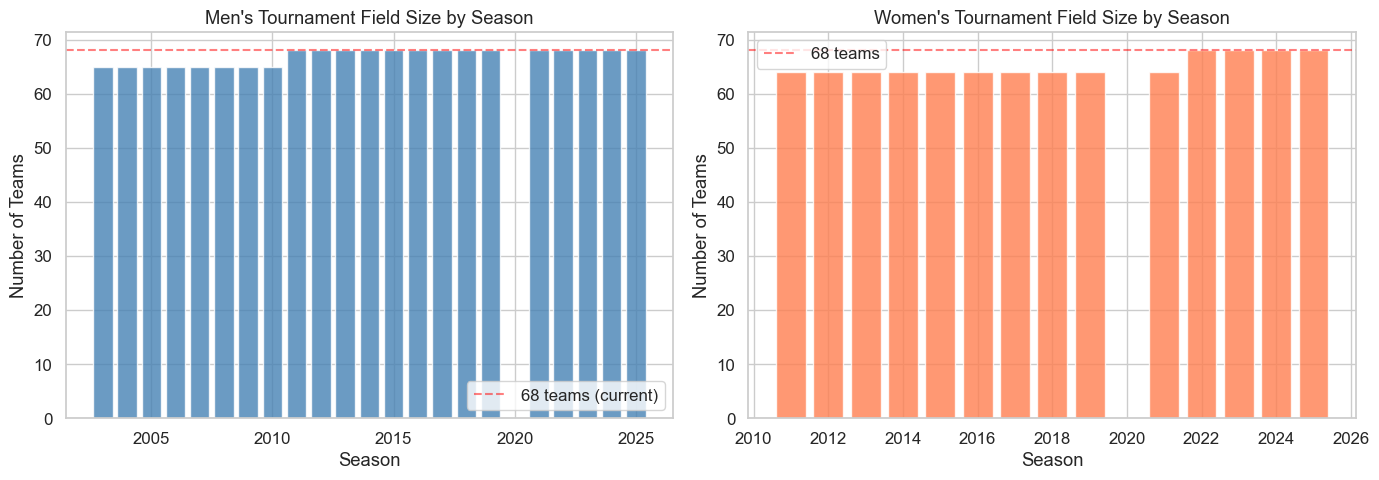

In [10]:
# Tournament field size over time
field_size = m_seeds.groupby('Season').size().reset_index(name='NumTeams')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(field_size['Season'], field_size['NumTeams'], color='steelblue', alpha=0.8)
axes[0].set_title("Men's Tournament Field Size by Season")
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Number of Teams')
axes[0].axhline(y=68, color='red', linestyle='--', alpha=0.5, label='68 teams (current)')
axes[0].legend()

w_field = w_seeds.groupby('Season').size().reset_index(name='NumTeams')
axes[1].bar(w_field['Season'], w_field['NumTeams'], color='coral', alpha=0.8)
axes[1].set_title("Women's Tournament Field Size by Season")
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Number of Teams')
axes[1].axhline(y=68, color='red', linestyle='--', alpha=0.5, label='68 teams')
axes[1].legend()

plt.tight_layout()
plt.show()

In [11]:
display(m_slots.tail(6))
# Bracket structure from slots
def extract_round(slot):
    if slot.startswith('R'):
        return int(slot[1])
    return 0  # play-in

m_slots_copy = m_slots.copy()
m_slots_copy['Round'] = m_slots_copy['Slot'].apply(extract_round)

round_names = {0: 'Play-In', 1: 'Round of 64', 2: 'Round of 32', 
               3: 'Sweet 16', 4: 'Elite 8', 5: 'Final Four', 6: 'Championship'}

games_per_round = m_slots_copy[m_slots_copy['Season'] == 2025].groupby('Round').size()
games_per_round.index = games_per_round.index.map(round_names)

print('Games per round (2025 Men\'s Tournament):')
print(games_per_round.to_string())

,Season,Slot,StrongSeed,WeakSeed
2580,2025,R5YZ,R4Y1,R4Z1
2581,2025,R6CH,R5WX,R5YZ
2582,2025,W16,W16a,W16b
2583,2025,X11,X11a,X11b
2584,2025,Y11,Y11a,Y11b
2585,2025,Y16,Y16a,Y16b


Games per round (2025 Men's Tournament):
Round
Play-In          4
Round of 64     32
Round of 32     16
Sweet 16         8
Elite 8          4
Final Four       2
Championship     1


<a id='4'></a>
## 4. Score Analysis

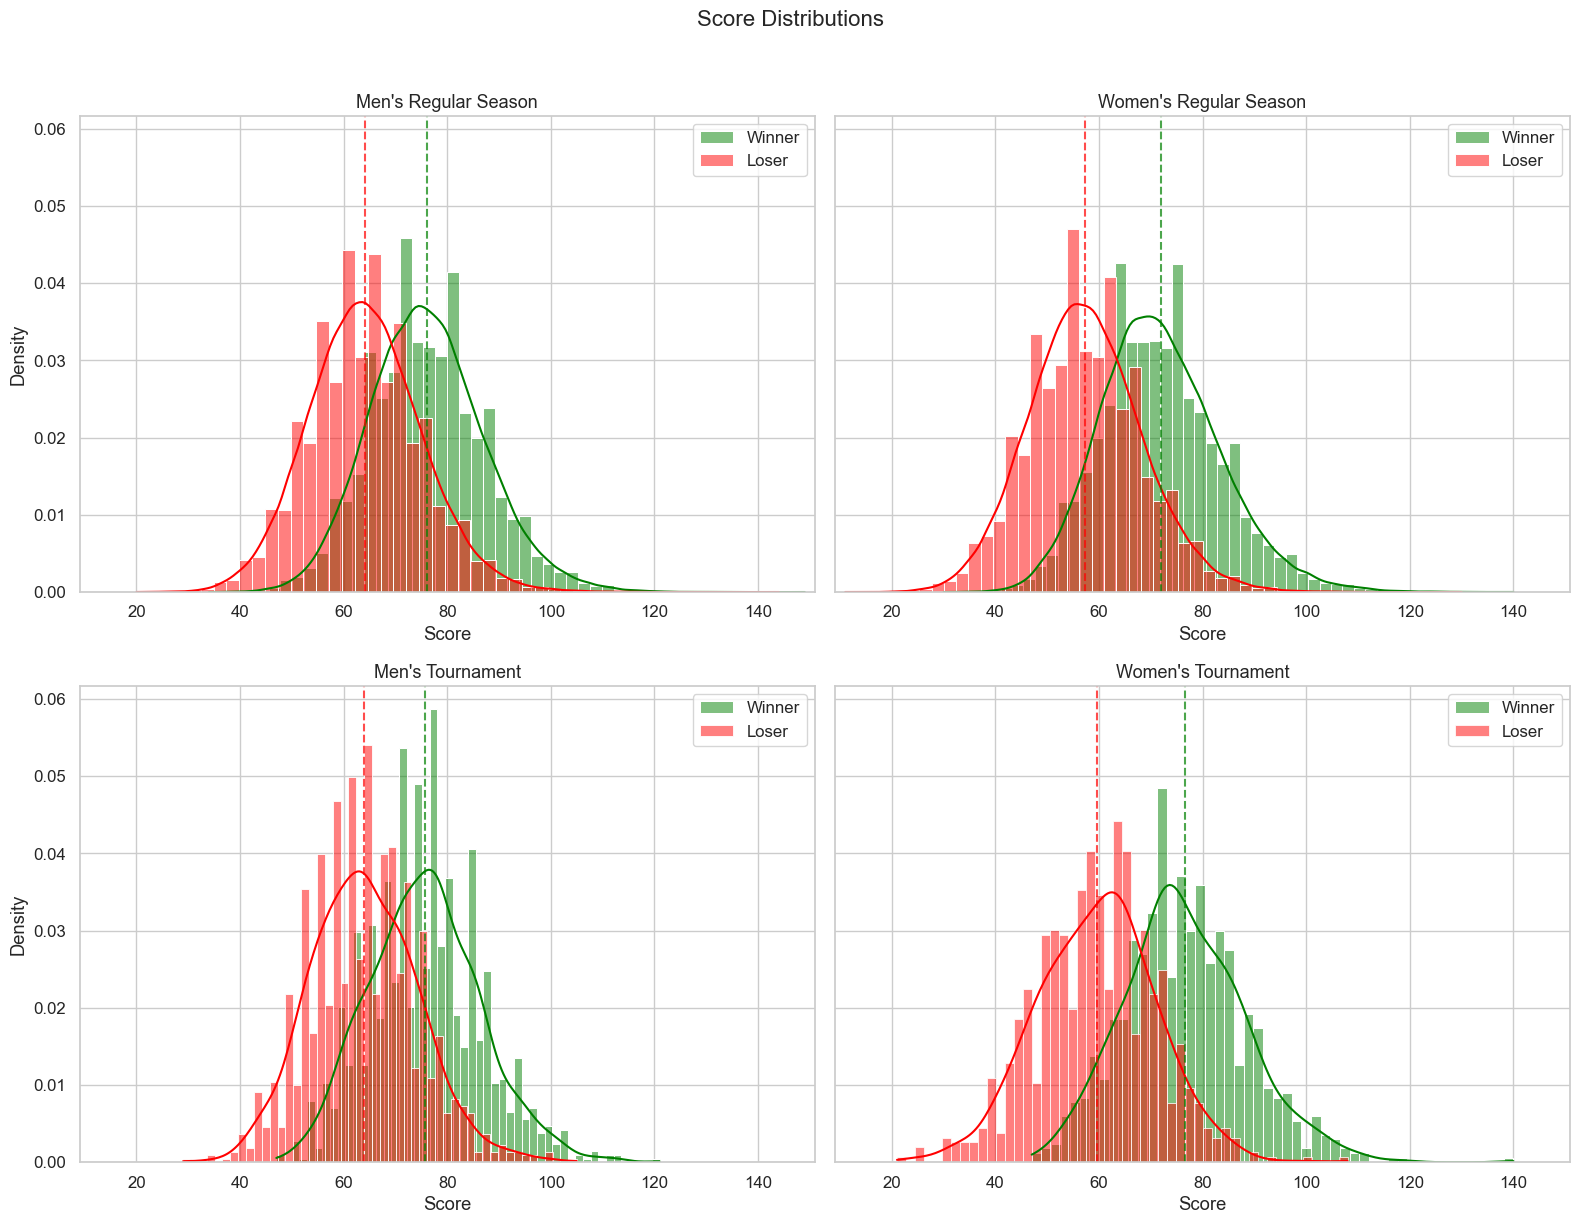

Men's Regular Season: Avg Winner=76.1, Avg Loser=64.1, Avg Margin=12.0
Women's Regular Season: Avg Winner=71.9, Avg Loser=57.3, Avg Margin=14.6
Men's Tournament: Avg Winner=75.6, Avg Loser=63.9, Avg Margin=11.7
Women's Tournament: Avg Winner=76.6, Avg Loser=59.5, Avg Margin=17.1


In [12]:
# Score distributions: Regular Season vs Tournament, Men vs Women
all_scores = pd.concat([
    m_rs_compact[['WScore','LScore']], w_rs_compact[['WScore','LScore']],
    m_tourney_compact[['WScore','LScore']], w_tourney_compact[['WScore','LScore']]
])
x_min = int(all_scores.min().min()) - 2
x_max = int(all_scores.max().max()) + 2

fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharey=True)

datasets_to_plot = [
    (m_rs_compact, "Men's Regular Season", axes[0, 0]),
    (w_rs_compact, "Women's Regular Season", axes[0, 1]),
    (m_tourney_compact, "Men's Tournament", axes[1, 0]),
    (w_tourney_compact, "Women's Tournament", axes[1, 1]),
]

for df, title, ax in datasets_to_plot:
    sns.histplot(df['WScore'], bins=50, kde=True, stat='density', color='green', alpha=0.5, label='Winner', ax=ax)
    sns.histplot(df['LScore'], bins=50, kde=True, stat='density', color='red', alpha=0.5, label='Loser', ax=ax)
    ax.axvline(df['WScore'].mean(), color='green', linestyle='--', alpha=0.7)
    ax.axvline(df['LScore'].mean(), color='red', linestyle='--', alpha=0.7)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Score')
    ax.set_ylabel('Density')
    ax.set_xlim(x_min, x_max)
    ax.legend()

plt.suptitle('Score Distributions', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

for df, title, _ in datasets_to_plot:
    print(f'{title}: Avg Winner={df["WScore"].mean():.1f}, Avg Loser={df["LScore"].mean():.1f}, '
          f'Avg Margin={df["WScore"].mean() - df["LScore"].mean():.1f}')


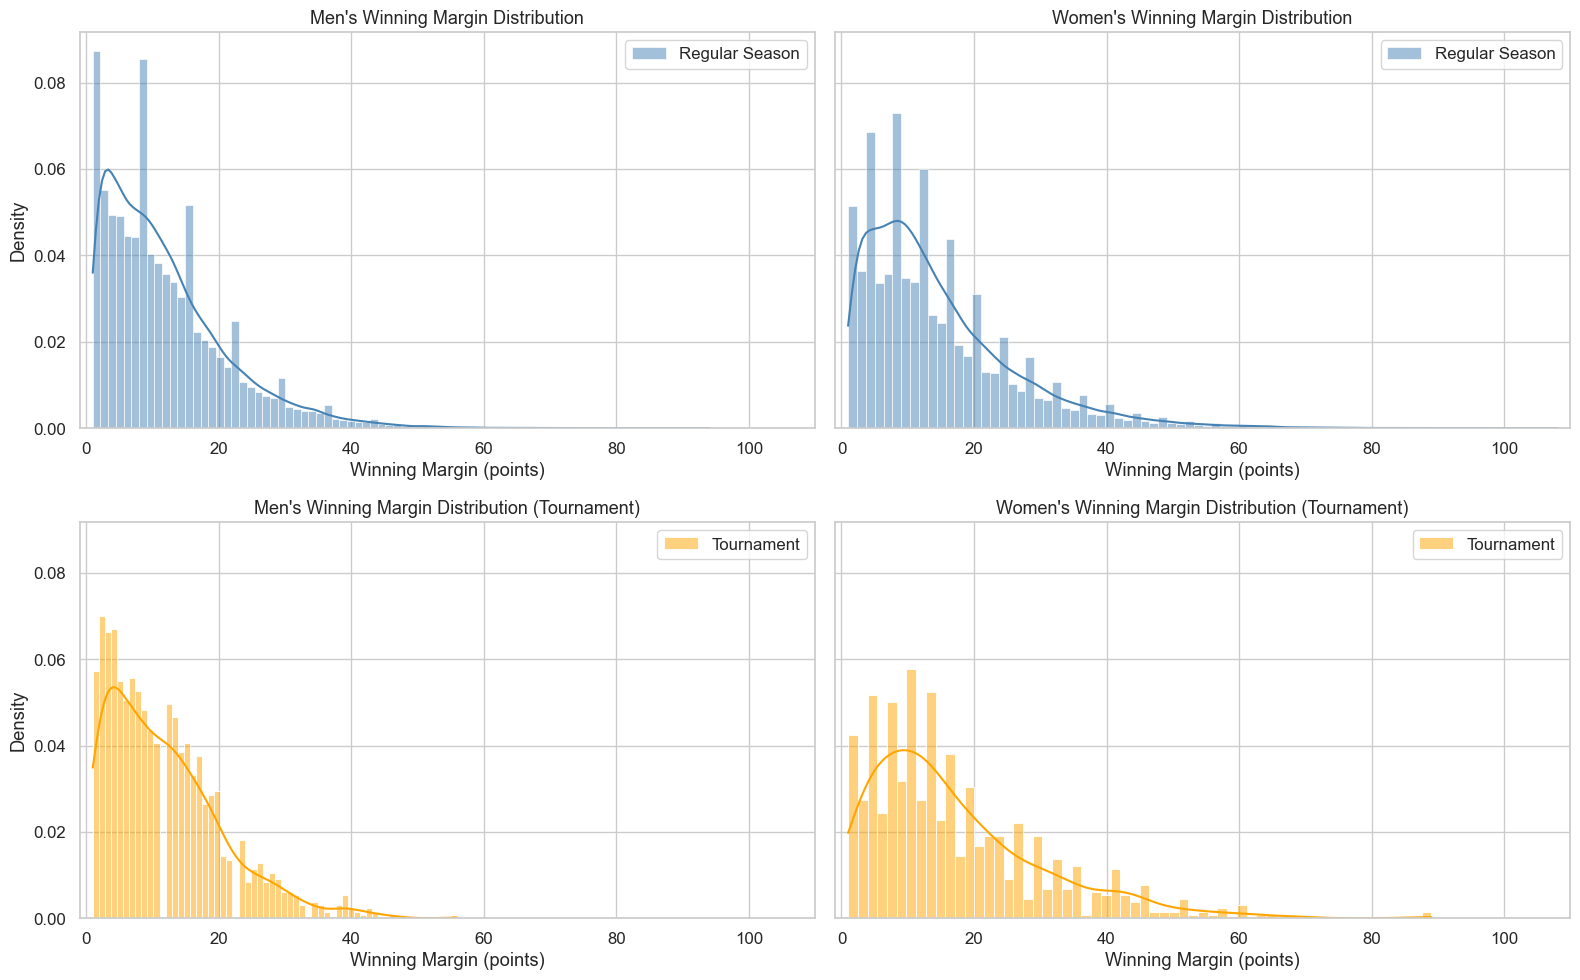

Men's RS avg margin: 12.0 | Tournament: 11.7
Women's RS avg margin: 14.6 | Tournament: 17.1


In [13]:
# Winning margin distributions
m_rs_compact_c = m_rs_compact.copy()
w_rs_compact_c = w_rs_compact.copy()
m_tourney_compact_c = m_tourney_compact.copy()
w_tourney_compact_c = w_tourney_compact.copy()
m_rs_compact_c['Margin'] = m_rs_compact_c['WScore'] - m_rs_compact_c['LScore']
w_rs_compact_c['Margin'] = w_rs_compact_c['WScore'] - w_rs_compact_c['LScore']
m_tourney_compact_c['Margin'] = m_tourney_compact_c['WScore'] - m_tourney_compact_c['LScore']
w_tourney_compact_c['Margin'] = w_tourney_compact_c['WScore'] - w_tourney_compact_c['LScore']

all_margins = pd.concat([
    m_rs_compact_c['Margin'], w_rs_compact_c['Margin'],
    m_tourney_compact_c['Margin'], w_tourney_compact_c['Margin']
])
x_min = int(all_margins.min()) - 2
x_max = int(all_margins.max()) + 2

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True)

sns.histplot(m_rs_compact_c['Margin'], bins=80, kde=True, stat='density', color='steelblue', alpha=0.5,
             label='Regular Season', ax=axes[0,0])
axes[0,0].set_title("Men's Winning Margin Distribution", fontsize=13)
axes[0,0].set_xlabel('Winning Margin (points)')
axes[0,0].set_ylabel('Density')
axes[0,0].set_xlim(x_min, x_max)
axes[0,0].legend()

sns.histplot(w_rs_compact_c['Margin'], bins=80, kde=True, stat='density', color='steelblue', alpha=0.5,
             label='Regular Season', ax=axes[0,1])
axes[0,1].set_title("Women's Winning Margin Distribution", fontsize=13)
axes[0,1].set_xlabel('Winning Margin (points)')
axes[0,1].set_xlim(x_min, x_max)
axes[0,1].legend()

sns.histplot(m_tourney_compact_c['Margin'], bins=60, kde=True, stat='density', color='orange', alpha=0.5,
             label='Tournament', ax=axes[1,0])
axes[1,0].set_title("Men's Winning Margin Distribution (Tournament)", fontsize=13)
axes[1,0].set_xlabel('Winning Margin (points)')
axes[1,0].set_ylabel('Density')
axes[1,0].set_xlim(x_min, x_max)
axes[1,0].legend()

sns.histplot(w_tourney_compact_c['Margin'], bins=60, kde=True, stat='density', color='orange', alpha=0.5,
             label='Tournament', ax=axes[1,1])
axes[1,1].set_title("Women's Winning Margin Distribution (Tournament)", fontsize=13)
axes[1,1].set_xlabel('Winning Margin (points)')
axes[1,1].set_xlim(x_min, x_max)
axes[1,1].legend()

plt.tight_layout()
plt.show()

print(f"Men's RS avg margin: {m_rs_compact_c['Margin'].mean():.1f} | Tournament: {m_tourney_compact_c['Margin'].mean():.1f}")
print(f"Women's RS avg margin: {w_rs_compact_c['Margin'].mean():.1f} | Tournament: {w_tourney_compact_c['Margin'].mean():.1f}")


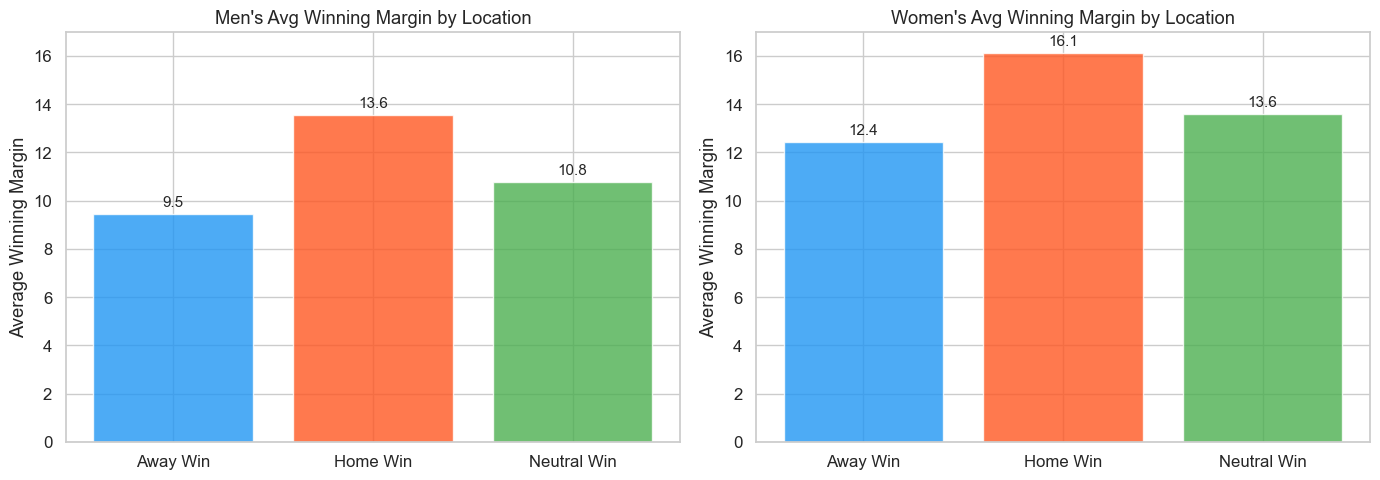

Men's home win %: 65.5% (72,965/111,403)
Women's home win %: 60.4% (45,104/74,638)


In [14]:
# Home court advantage analysis (regular season only)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (df, label) in enumerate([(m_rs_compact_c, "Men's"), (w_rs_compact_c, "Women's")]):
    loc_stats = df.groupby('WLoc').agg(
        count=('WScore', 'size'),
        avg_margin=('Margin', 'mean')
    ).reset_index()
    loc_stats['WLoc'] = loc_stats['WLoc'].map({'H': 'Home Win', 'A': 'Away Win', 'N': 'Neutral Win'})
    
    bars = axes[idx].bar(loc_stats['WLoc'], loc_stats['avg_margin'], 
                         color=['#2196F3', '#FF5722', '#4CAF50'], alpha=0.8)
    for bar, val in zip(bars, loc_stats['avg_margin']):
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                      f'{val:.1f}', ha='center', fontsize=11)
    axes[idx].set_title(f"{label} Avg Winning Margin by Location")
    axes[idx].set_ylabel('Average Winning Margin')
    axes[idx].set_ylim([0,17])


plt.tight_layout()
plt.show()

# Home win percentage
for df, label in [(m_rs_compact, "Men's"), (w_rs_compact, "Women's")]:
    home_away = df[df['WLoc'].isin(['H', 'A'])]
    home_wins = (home_away['WLoc'] == 'H').sum()
    total = len(home_away)
    print(f"{label} home win %: {home_wins/total*100:.1f}% ({home_wins:,}/{total:,})")

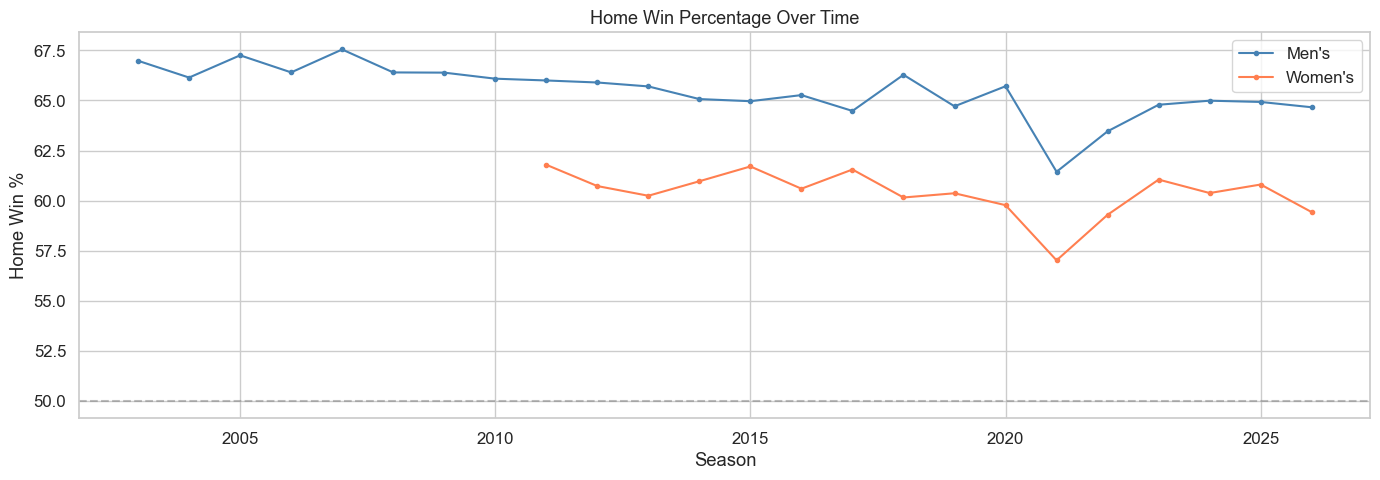

In [15]:
# Home win percentage trend over seasons
fig, ax = plt.subplots(figsize=(14, 5))

for df, label, color in [(m_rs_compact, "Men's", 'steelblue'), (w_rs_compact, "Women's", 'coral')]:
    home_away = df[df['WLoc'].isin(['H', 'A'])].copy()
    home_away['HomeWin'] = (home_away['WLoc'] == 'H').astype(int)
    trend = home_away.groupby('Season')['HomeWin'].mean()
    ax.plot(trend.index, trend.values * 100, marker='o', markersize=3, label=label, color=color)

ax.set_title('Home Win Percentage Over Time', fontsize=13)
ax.set_xlabel('Season')
ax.set_ylabel('Home Win %')
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()

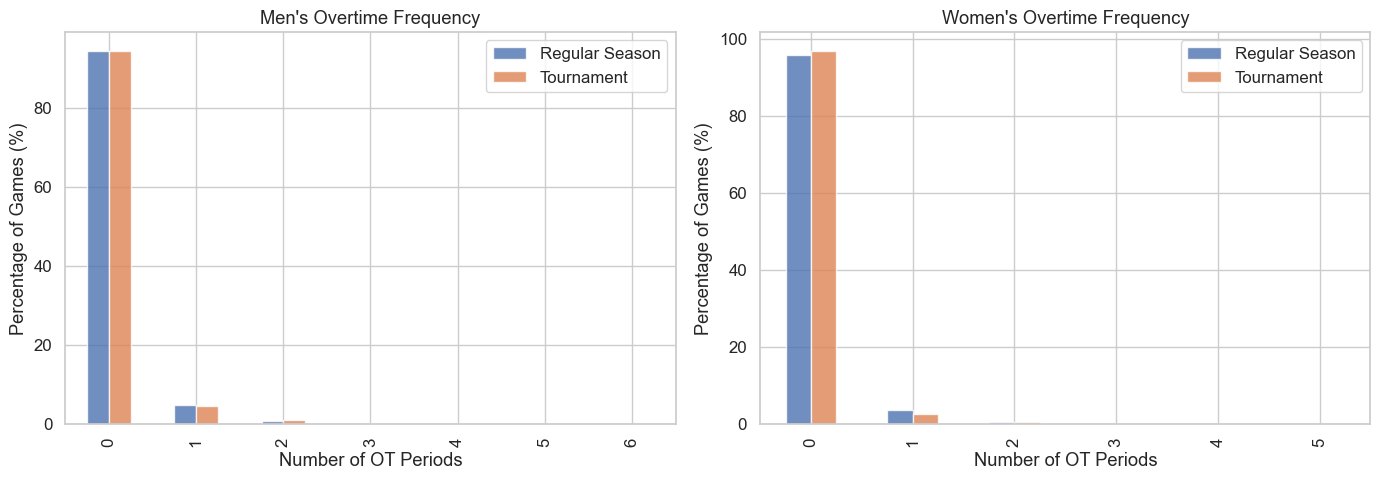

Men's RS: 5.67% games go to overtime
Men's Tourney: 5.52% games go to overtime
Women's RS: 4.37% games go to overtime
Women's Tourney: 3.12% games go to overtime


In [16]:
# Overtime analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (rs, tn, label) in enumerate([
    (m_rs_compact, m_tourney_compact, "Men's"),
    (w_rs_compact, w_tourney_compact, "Women's")
]):
    rs_ot = rs['NumOT'].value_counts().sort_index()
    tn_ot = tn['NumOT'].value_counts().sort_index()
    
    ot_df = pd.DataFrame({'Regular Season': rs_ot, 'Tournament': tn_ot}).fillna(0)
    # Convert to percentages
    ot_pct = ot_df.div(ot_df.sum()) * 100
    
    ot_pct.plot(kind='bar', ax=axes[idx], alpha=0.8)
    axes[idx].set_title(f"{label} Overtime Frequency")
    axes[idx].set_xlabel('Number of OT Periods')
    axes[idx].set_ylabel('Percentage of Games (%)')
    axes[idx].legend()

plt.tight_layout()
plt.show()

for df, label in [(m_rs_compact, "Men's RS"), (m_tourney_compact, "Men's Tourney"),
                   (w_rs_compact, "Women's RS"), (w_tourney_compact, "Women's Tourney")]:
    ot_rate = (df['NumOT'] > 0).mean() * 100
    print(f"{label}: {ot_rate:.2f}% games go to overtime")

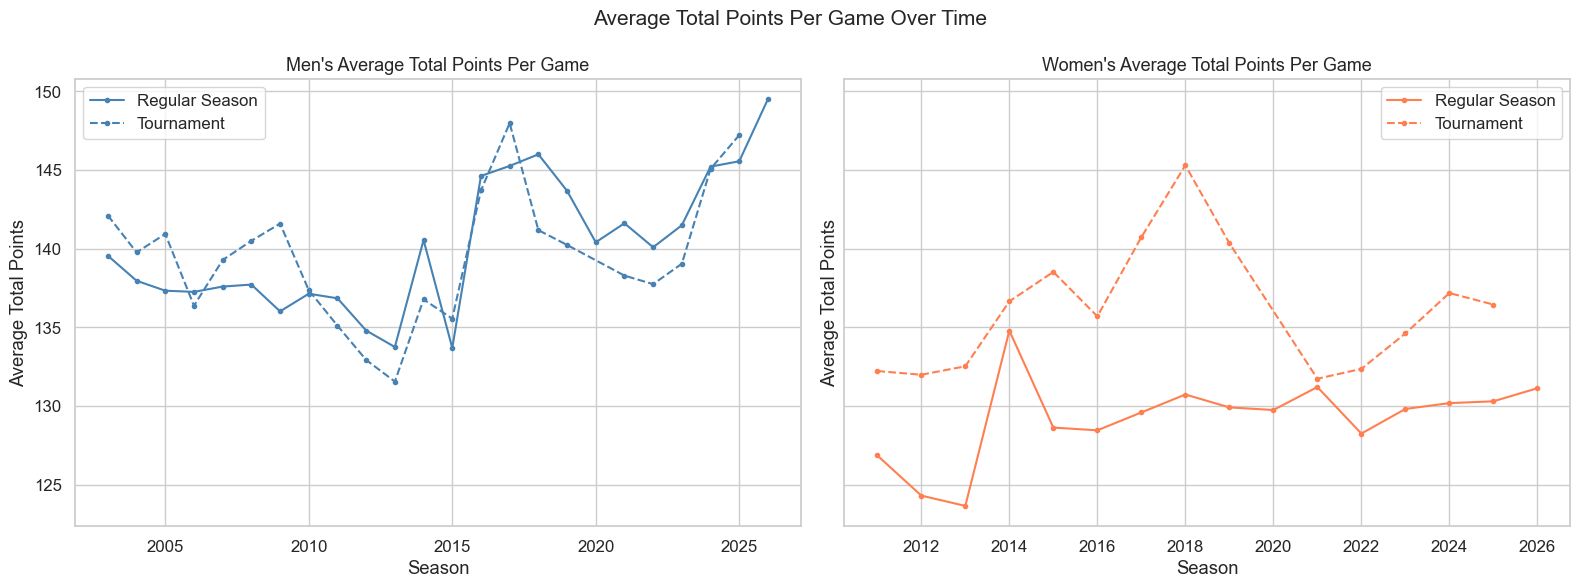

In [17]:
# Total points per game trend
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, datasets, title in [
    (axes[0], [
        (m_rs_compact, "Regular Season", 'steelblue', '-'),
        (m_tourney_compact, "Tournament", 'steelblue', '--'),
    ], "Men's Average Total Points Per Game"),
    (axes[1], [
        (w_rs_compact, "Regular Season", 'coral', '-'),
        (w_tourney_compact, "Tournament", 'coral', '--'),
    ], "Women's Average Total Points Per Game"),
]:
    for df, label, color, ls in datasets:
        total = df.copy()
        total['TotalPoints'] = total['WScore'] + total['LScore']
        trend = total.groupby('Season')['TotalPoints'].mean()
        ax.plot(trend.index, trend.values, marker='o', markersize=3, label=label, color=color, linestyle=ls)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Season')
    ax.set_ylabel('Average Total Points')
    ax.legend()

plt.suptitle('Average Total Points Per Game Over Time', fontsize=15)
plt.tight_layout()
plt.show()


<a id='5'></a>
## 5. Team Performance Analysis

In [18]:
# Build team-season summary stats (reusable function)
def build_team_season_stats(compact_results, teams_df):
    """Build per-team, per-season summary from compact results."""
    wins = compact_results.groupby(['Season', 'WTeamID']).agg(
        Wins=('WScore', 'size'),
        PointsFor_W=('WScore', 'sum'),
        PointsAgainst_W=('LScore', 'sum')
    ).reset_index().rename(columns={'WTeamID': 'TeamID'})

    losses = compact_results.groupby(['Season', 'LTeamID']).agg(
        Losses=('LScore', 'size'),
        PointsFor_L=('LScore', 'sum'),
        PointsAgainst_L=('WScore', 'sum')
    ).reset_index().rename(columns={'LTeamID': 'TeamID'})

    team_stats = pd.merge(wins, losses, on=['Season', 'TeamID'], how='outer').fillna(0)
    team_stats['GamesPlayed'] = team_stats['Wins'] + team_stats['Losses']
    team_stats['WinPct'] = team_stats['Wins'] / team_stats['GamesPlayed']
    team_stats['PointsFor'] = team_stats['PointsFor_W'] + team_stats['PointsFor_L']
    team_stats['PointsAgainst'] = team_stats['PointsAgainst_W'] + team_stats['PointsAgainst_L']
    team_stats['PPG'] = team_stats['PointsFor'] / team_stats['GamesPlayed']
    team_stats['OPPG'] = team_stats['PointsAgainst'] / team_stats['GamesPlayed']
    team_stats['PointDiff'] = team_stats['PPG'] - team_stats['OPPG']

    name_col = 'TeamName'
    return team_stats.merge(teams_df[['TeamID', name_col]], on='TeamID', how='left')

m_team_stats = build_team_season_stats(m_rs_compact, m_teams)
w_team_stats = build_team_season_stats(w_rs_compact, w_teams)

print(f"Men's team-season records: {len(m_team_stats):,}")
print(f"Women's team-season records: {len(w_team_stats):,}")
m_team_stats.sort_values('WinPct', ascending=False).head(10)

Men's team-season records: 8,346
Women's team-season records: 5,622


,Season,TeamID,Wins,PointsFor_W,PointsAgainst_W,Losses,PointsFor_L,PointsAgainst_L,GamesPlayed,WinPct,PointsFor,PointsAgainst,PPG,OPPG,PointDiff,TeamName
8147,2026,1275,26.0,2262.0,1947.0,0.0,0.0,0.0,26.0,1.000000,2262.0,1947.0,87.000000,74.884615,12.115385,Miami OH
6286,2021,1211,26.0,2395.0,1797.0,0.0,0.0,0.0,26.0,1.000000,2395.0,1797.0,92.115385,69.115385,23.000000,Gonzaga
4067,2014,1455,33.0,2473.0,1976.0,0.0,0.0,0.0,33.0,1.000000,2473.0,1976.0,74.939394,59.878788,15.060606,Wichita St
4215,2015,1246,34.0,2547.0,1835.0,0.0,0.0,0.0,34.0,1.000000,2547.0,1835.0,74.911765,53.970588,20.941176,Kentucky
1812,2008,1272,33.0,2647.0,1995.0,1.0,62.0,66.0,34.0,0.970588,2709.0,2061.0,79.676471,60.617647,19.058824,Memphis
4883,2017,1211,32.0,2720.0,1939.0,1.0,71.0,79.0,33.0,0.969697,2791.0,2018.0,84.575758,61.151515,23.424242,Gonzaga
767,2005,1228,32.0,2491.0,1919.0,1.0,64.0,65.0,33.0,0.969697,2555.0,1984.0,77.424242,60.121212,17.303030,Illinois
583,2004,1390,29.0,2156.0,1746.0,1.0,62.0,75.0,30.0,0.966667,2218.0,1821.0,73.933333,60.700000,13.233333,Stanford
579,2004,1386,27.0,2111.0,1635.0,1.0,67.0,87.0,28.0,0.964286,2178.0,1722.0,77.785714,61.500000,16.285714,St Joseph's PA
3214,2012,1293,27.0,2010.0,1674.0,1.0,68.0,72.0,28.0,0.964286,2078.0,1746.0,74.214286,62.357143,11.857143,Murray St


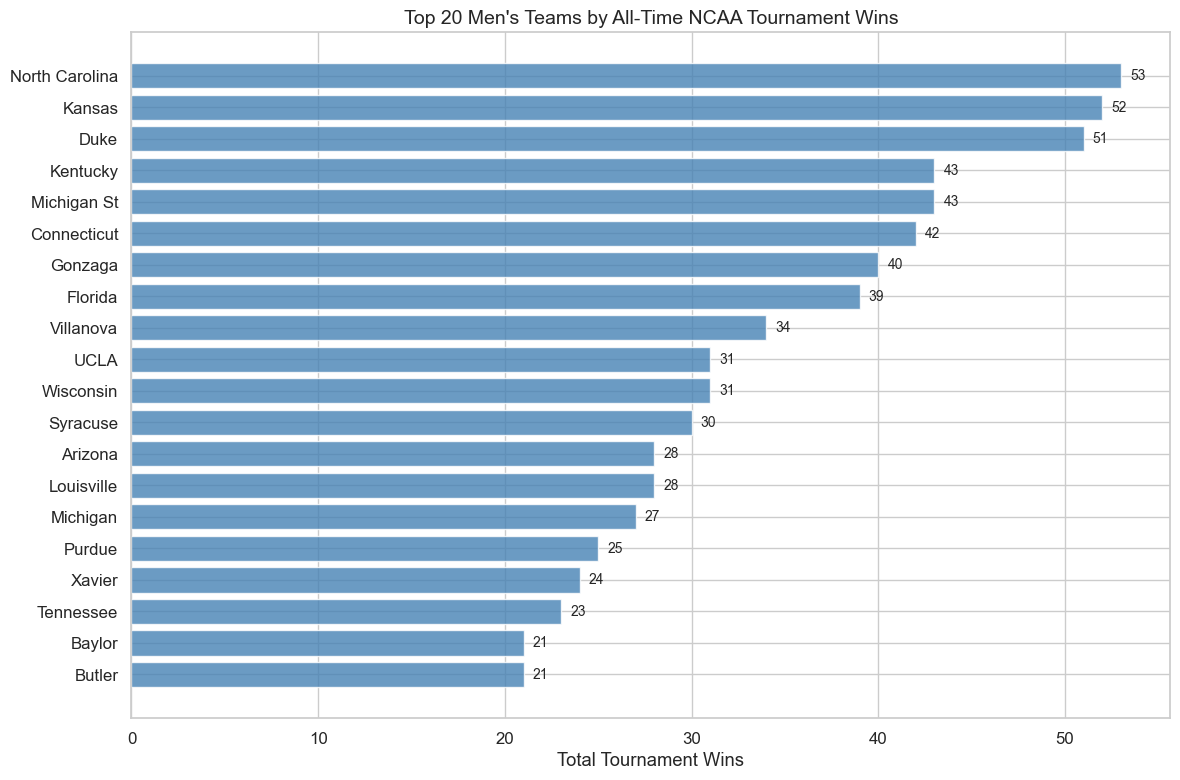

In [19]:
# Top 20 teams by all-time tournament wins (Men's)
m_tourney_wins = m_tourney_compact.groupby('WTeamID').size().reset_index(name='TourneyWins')
m_tourney_wins = m_tourney_wins.merge(m_teams[['TeamID', 'TeamName']], 
                                       left_on='WTeamID', right_on='TeamID')
top20 = m_tourney_wins.nlargest(20, 'TourneyWins')

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(range(len(top20)), top20['TourneyWins'].values, color='steelblue', alpha=0.8)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20['TeamName'].values)
ax.invert_yaxis()
ax.set_xlabel('Total Tournament Wins')
ax.set_title("Top 20 Men's Teams by All-Time NCAA Tournament Wins", fontsize=14)

for bar, val in zip(bars, top20['TourneyWins'].values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, str(val),
            va='center', fontsize=10)

plt.tight_layout()
plt.show()

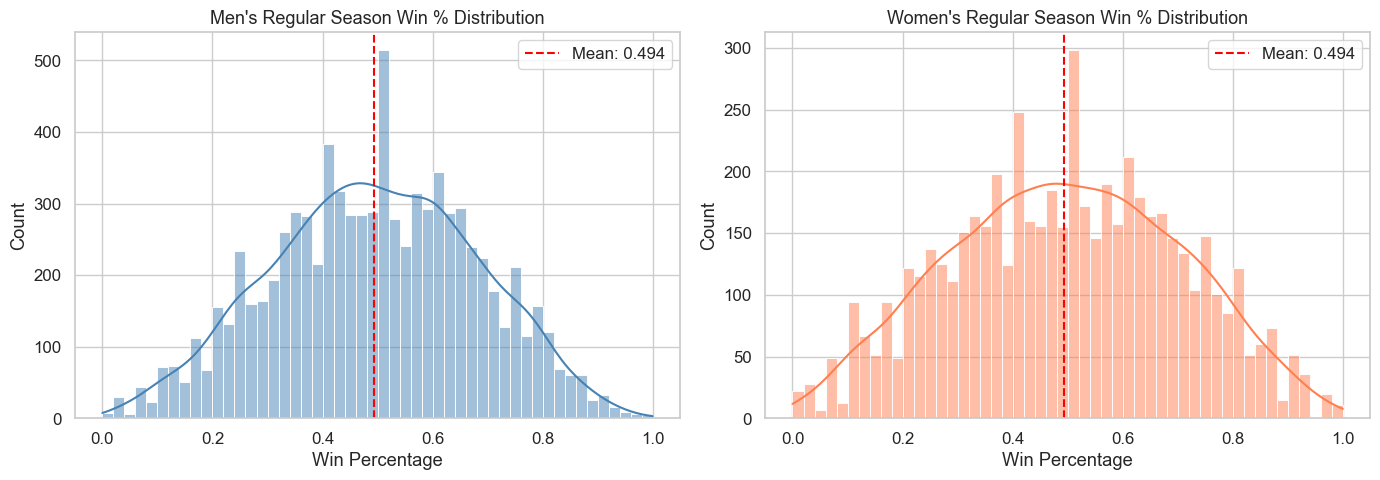

In [20]:
# Win percentage distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(m_team_stats['WinPct'], bins=50, kde=True, color='steelblue', ax=axes[0])
axes[0].axvline(m_team_stats['WinPct'].mean(), color='red', linestyle='--', label=f"Mean: {m_team_stats['WinPct'].mean():.3f}")
axes[0].set_title("Men's Regular Season Win % Distribution", fontsize=13)
axes[0].set_xlabel('Win Percentage')
axes[0].legend()

sns.histplot(w_team_stats['WinPct'], bins=50, kde=True, color='coral', ax=axes[1])
axes[1].axvline(w_team_stats['WinPct'].mean(), color='red', linestyle='--', label=f"Mean: {w_team_stats['WinPct'].mean():.3f}")
axes[1].set_title("Women's Regular Season Win % Distribution", fontsize=13)
axes[1].set_xlabel('Win Percentage')
axes[1].legend()

plt.tight_layout()
plt.show()

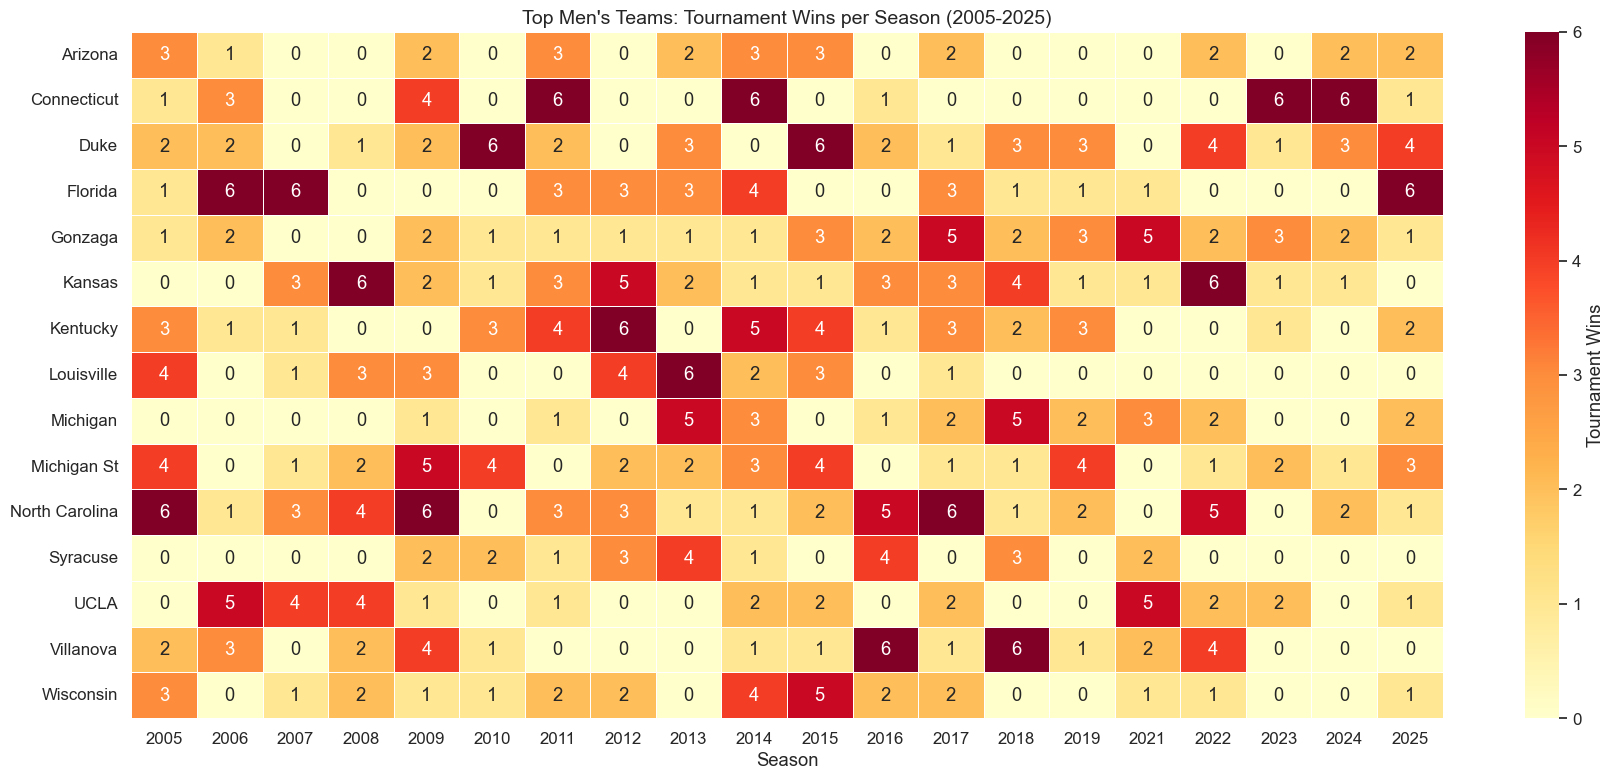

In [21]:
# Dynasty heatmap: top men's teams tournament performance by season
def get_tourney_wins_by_team_season(tourney_compact, seeds):
    """Count tournament wins per team per season."""
    wins = tourney_compact.groupby(['Season', 'WTeamID']).size().reset_index(name='TourneyWins')
    wins.rename(columns={'WTeamID': 'TeamID'}, inplace=True)
    return wins

m_tw = get_tourney_wins_by_team_season(m_tourney_compact, m_seeds)

# Get top 15 teams by total tourney wins
top15_ids = m_tw.groupby('TeamID')['TourneyWins'].sum().nlargest(15).index.tolist()
top15_data = m_tw[m_tw['TeamID'].isin(top15_ids)].copy()
top15_data = top15_data.merge(m_teams[['TeamID', 'TeamName']], on='TeamID')

# Pivot for heatmap
pivot = top15_data.pivot_table(index='TeamName', columns='Season', values='TourneyWins', fill_value=0)
# Only show recent 20 seasons
recent_seasons = [s for s in range(2005, 2026) if s in pivot.columns]
pivot = pivot[recent_seasons]

fig, ax = plt.subplots(figsize=(18, 8))
sns.heatmap(pivot, annot=True, fmt='g', cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': 'Tournament Wins'}, ax=ax)
ax.set_title("Top Men's Teams: Tournament Wins per Season (2005-2025)", fontsize=14)
ax.set_xlabel('Season')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [22]:
# Scoring power vs defensive strength (most recent complete season)
latest_season = m_team_stats[m_team_stats['Season'] == 2025].copy()
latest_season = latest_season.merge(
    m_seeds[m_seeds['Season'] == 2025][['TeamID']].assign(InTourney=True),
    on='TeamID', how='left'
)
latest_season['InTourney'] = latest_season['InTourney'].fillna(False)

fig = px.scatter(
    latest_season, x='PPG', y='OPPG', color='InTourney',
    hover_data=['TeamName', 'Wins', 'Losses', 'WinPct'],
    size='Wins', size_max=15,
    color_discrete_map={True: '#2196F3', False: '#BDBDBD'},
    title="Men's 2025: Offensive vs Defensive Performance",
    labels={'PPG': 'Points Per Game (Offense)', 'OPPG': 'Opponent PPG (Defense)',
            'InTourney': 'Tournament Team'}
)
fig.update_layout(width=900, height=600)
fig.show()

<a id='6'></a>
## 6. Box Score (Detailed Stats) Analysis

In [23]:
# Compute derived stats for detailed results
def add_derived_stats(df):
    """Add shooting percentages and derived stats."""
    for p in ['W', 'L']:
        df[f'{p}FGPct'] = df[f'{p}FGM'] / df[f'{p}FGA']
        df[f'{p}FG3Pct'] = df[f'{p}FGM3'] / df[f'{p}FGA3']
        df[f'{p}FTPct'] = df[f'{p}FTM'] / df[f'{p}FTA'].replace(0, np.nan)
        df[f'{p}TotalReb'] = df[f'{p}OR'] + df[f'{p}DR']
        df[f'{p}AstTO'] = df[f'{p}Ast'] / df[f'{p}TO'].replace(0, np.nan)
        df[f'{p}eFGPct'] = (df[f'{p}FGM'] + 0.5 * df[f'{p}FGM3']) / df[f'{p}FGA']
        score_col = 'WScore' if p == 'W' else 'LScore'
        df[f'{p}TSPct'] = df[score_col] / (2 * (df[f'{p}FGA'] + 0.44 * df[f'{p}FTA']))
    return df

m_rs_detail = add_derived_stats(m_rs_detail)
w_rs_detail = add_derived_stats(w_rs_detail)
m_tourney_detail = add_derived_stats(m_tourney_detail)
w_tourney_detail = add_derived_stats(w_tourney_detail)

print('Derived stats computed.')
print(f"Sample derived cols: {[c for c in m_rs_detail.columns if 'Pct' in c or 'TS' in c]}")

Derived stats computed.
Sample derived cols: ['WFGPct', 'WFG3Pct', 'WFTPct', 'WeFGPct', 'WTSPct', 'LFGPct', 'LFG3Pct', 'LFTPct', 'LeFGPct', 'LTSPct']


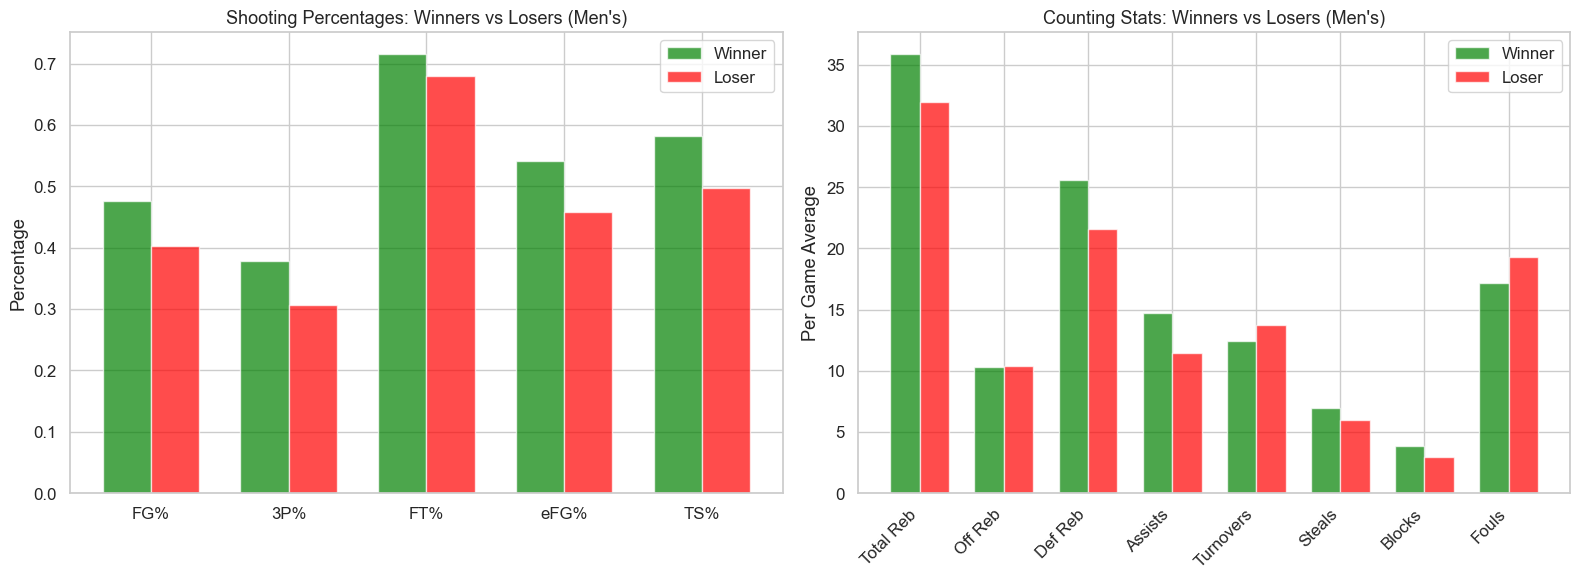


Winner vs Loser averages (Men's Regular Season):


,Winner,Loser
FG%,0.475,0.403
3P%,0.379,0.306
FT%,0.716,0.680
eFG%,0.542,0.459
TS%,0.583,0.497
Total Reb,35.883,31.939
Off Reb,10.303,10.372
Def Reb,25.580,21.567
Assists,14.735,11.436
Turnovers,12.436,13.721


In [24]:
# Winners vs Losers stat comparison
stat_labels = {
    'FGPct': 'FG%', 'FG3Pct': '3P%', 'FTPct': 'FT%', 'eFGPct': 'eFG%', 'TSPct': 'TS%',
    'TotalReb': 'Total Reb', 'OR': 'Off Reb', 'DR': 'Def Reb',
    'Ast': 'Assists', 'TO': 'Turnovers', 'Stl': 'Steals', 'Blk': 'Blocks', 'PF': 'Fouls'
}

winner_means = {}
loser_means = {}
for stat in stat_labels:
    winner_means[stat_labels[stat]] = m_rs_detail[f'W{stat}'].mean()
    loser_means[stat_labels[stat]] = m_rs_detail[f'L{stat}'].mean()

comparison_df = pd.DataFrame({'Winner': winner_means, 'Loser': loser_means})

# Separate percentage stats from counting stats
pct_stats = ['FG%', '3P%', 'FT%', 'eFG%', 'TS%']
count_stats = [s for s in comparison_df.index if s not in pct_stats]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Percentage stats
pct_data = comparison_df.loc[pct_stats]
x = np.arange(len(pct_stats))
w = 0.35
axes[0].bar(x - w/2, pct_data['Winner'], w, label='Winner', color='green', alpha=0.7)
axes[0].bar(x + w/2, pct_data['Loser'], w, label='Loser', color='red', alpha=0.7)
axes[0].set_xticks(x)
axes[0].set_xticklabels(pct_stats)
axes[0].set_title("Shooting Percentages: Winners vs Losers (Men's)", fontsize=13)
axes[0].set_ylabel('Percentage')
axes[0].legend()

# Counting stats
cnt_data = comparison_df.loc[count_stats]
x2 = np.arange(len(count_stats))
axes[1].bar(x2 - w/2, cnt_data['Winner'], w, label='Winner', color='green', alpha=0.7)
axes[1].bar(x2 + w/2, cnt_data['Loser'], w, label='Loser', color='red', alpha=0.7)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(count_stats, rotation=45, ha='right')
axes[1].set_title("Counting Stats: Winners vs Losers (Men's)", fontsize=13)
axes[1].set_ylabel('Per Game Average')
axes[1].legend()

plt.tight_layout()
plt.show()

print('\nWinner vs Loser averages (Men\'s Regular Season):')
display(comparison_df.round(3))

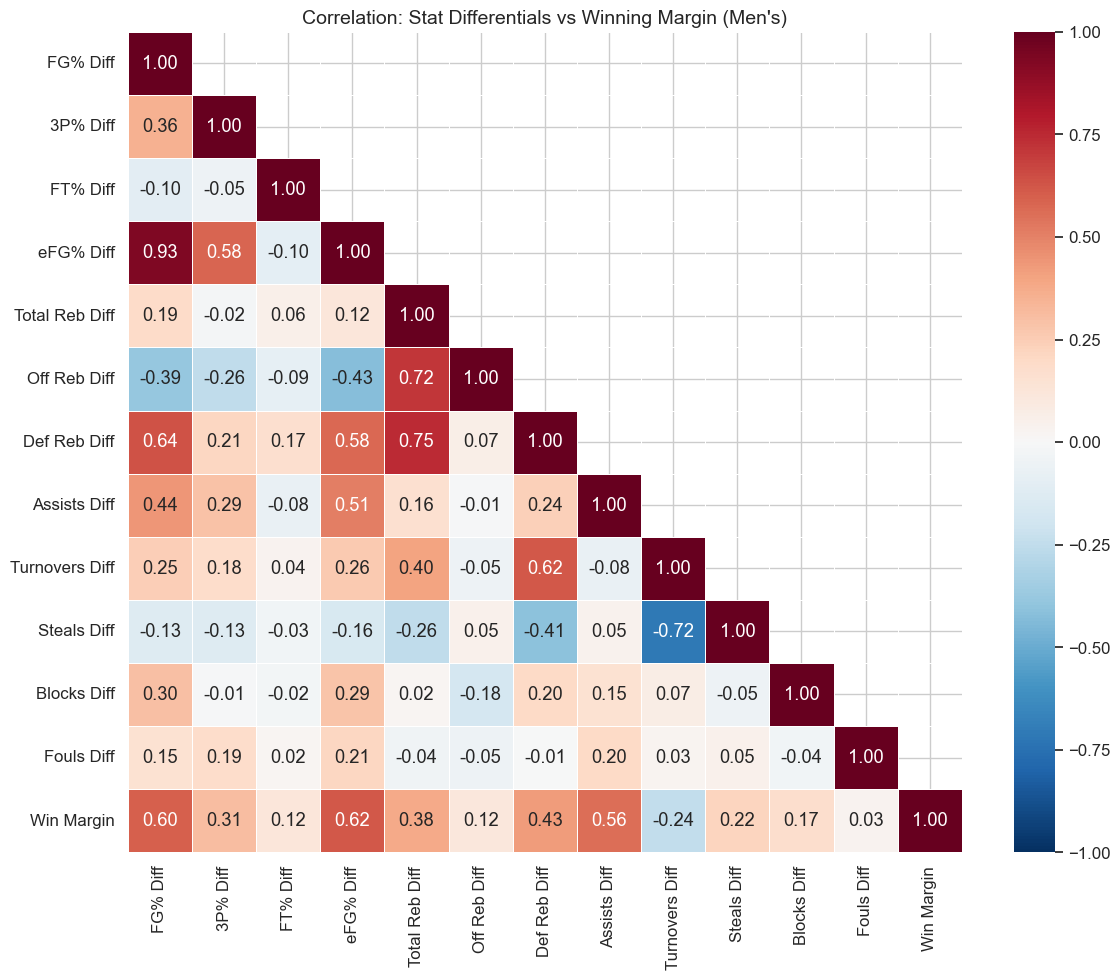

In [25]:
# Correlation heatmap: stat differentials vs winning margin
diff_stats = ['FGPct', 'FG3Pct', 'FTPct', 'eFGPct', 'TotalReb', 'OR', 'DR', 'Ast', 'TO', 'Stl', 'Blk', 'PF']

m_detail_diff = m_rs_detail.copy()
m_detail_diff['Margin'] = m_detail_diff['WScore'] - m_detail_diff['LScore']

for stat in diff_stats:
    m_detail_diff[f'Diff_{stat}'] = m_detail_diff[f'W{stat}'] - m_detail_diff[f'L{stat}']

diff_cols = [f'Diff_{s}' for s in diff_stats] + ['Margin']
corr_matrix = m_detail_diff[diff_cols].corr()

# Rename for display
rename_map = {f'Diff_{s}': f'{stat_labels.get(s, s)} Diff' for s in diff_stats}
rename_map['Margin'] = 'Win Margin'
corr_display = corr_matrix.rename(index=rename_map, columns=rename_map)

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_display, dtype=bool), k=1)
sns.heatmap(corr_display, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=mask, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title("Correlation: Stat Differentials vs Winning Margin (Men's)", fontsize=14)
plt.tight_layout()
plt.show()

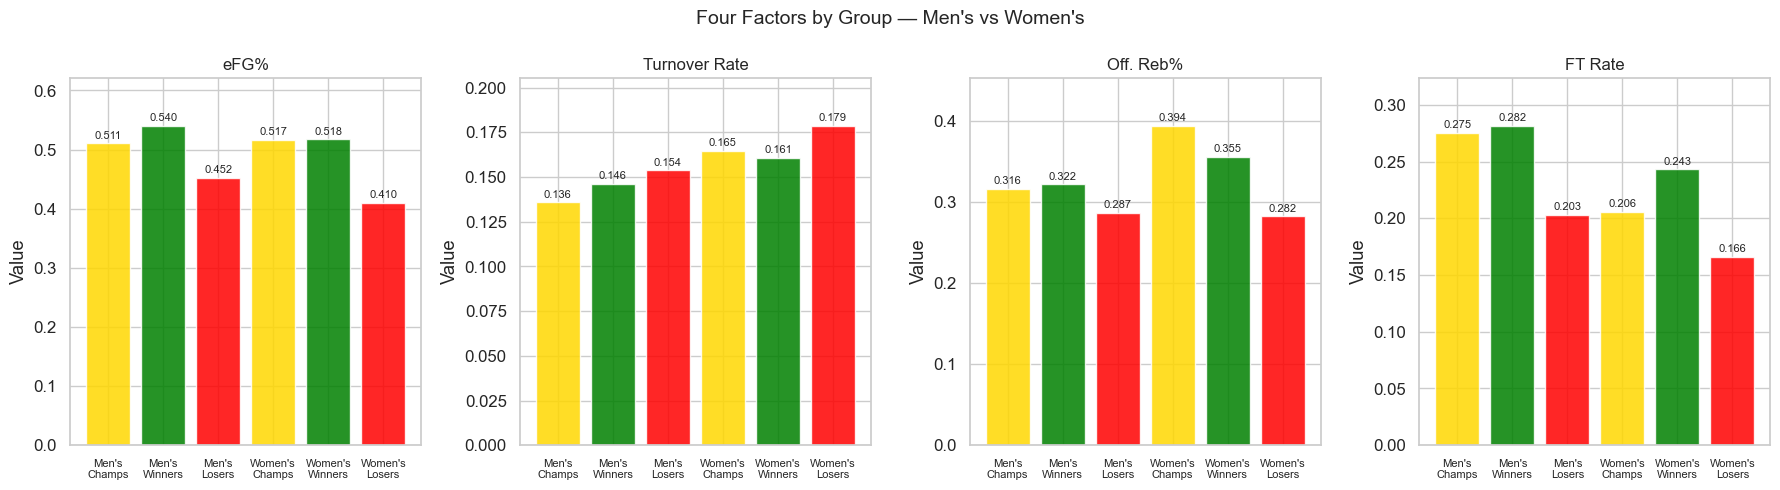

In [26]:
# Four Factors analysis
def compute_four_factors(detail_df, prefix='W'):
    """Compute Dean Oliver Four Factors."""
    p = prefix
    opp = 'L' if prefix == 'W' else 'W'
    return pd.DataFrame({
        'eFG%':   (detail_df[f'{p}FGM'] + 0.5 * detail_df[f'{p}FGM3']) / detail_df[f'{p}FGA'],
        'TORate': detail_df[f'{p}TO'] / (detail_df[f'{p}FGA'] + 0.44 * detail_df[f'{p}FTA'] + detail_df[f'{p}TO']),
        'OReb%':  detail_df[f'{p}OR'] / (detail_df[f'{p}OR'] + detail_df[f'{opp}DR']),
        'FTRate': detail_df[f'{p}FTM'] / detail_df[f'{p}FGA'],
    })

categories = ['eFG%', 'TORate', 'OReb%', 'FTRate']
factor_labels = {'eFG%': 'eFG%', 'TORate': 'Turnover Rate', 'OReb%': 'Off. Reb%', 'FTRate': 'FT Rate'}

configs = [
    (m_tourney_detail, "Men's",   '#1565C0'),
    (w_tourney_detail, "Women's", '#AD1457'),
]

# 1. Radar charts side by side
from plotly.subplots import make_subplots
fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'polar'}, {'type': 'polar'}]],
    subplot_titles=[label + ' Four Factors' for _, label, _ in configs]
)

for col_idx, (detail_df, label, color) in enumerate(configs, start=1):
    finals = detail_df[detail_df['DayNum'] == detail_df.groupby('Season')['DayNum'].transform('max')]
    champ_ff       = compute_four_factors(finals, 'W').mean()
    all_winners_ff = compute_four_factors(detail_df, 'W').mean()
    all_losers_ff  = compute_four_factors(detail_df, 'L').mean()
    for name, ff, clr, width in [
        ('Champions',   champ_ff,       'gold',  3),
        ('All Winners', all_winners_ff, 'green', 2),
        ('All Losers',  all_losers_ff,  'red',   2),
    ]:
        fig.add_trace(go.Scatterpolar(
            r=ff.values, theta=categories, fill='toself',
            name=label + ' ' + name,
            line=dict(color=clr, width=width),
            showlegend=(col_idx == 1)
        ), row=1, col=col_idx)

fig.update_layout(
    height=500, width=950,
    title_text="Four Factors: Champions vs Tournament Field",
    legend=dict(orientation='h', y=-0.15)
)
fig.show()

# 2. Bar charts per factor — łatwe porównanie wartości
fig2, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, factor in zip(axes, categories):
    rows = []
    for detail_df, label, _ in configs:
        finals = detail_df[detail_df['DayNum'] == detail_df.groupby('Season')['DayNum'].transform('max')]
        rows.append({'Group': label + '\nChamps',   'val': compute_four_factors(finals, 'W')[factor].mean()})
        rows.append({'Group': label + '\nWinners',  'val': compute_four_factors(detail_df, 'W')[factor].mean()})
        rows.append({'Group': label + '\nLosers',   'val': compute_four_factors(detail_df, 'L')[factor].mean()})
    tmp = pd.DataFrame(rows)
    bar_colors = ['gold', 'green', 'red', 'gold', 'green', 'red']
    bars = ax.bar(tmp['Group'], tmp['val'], color=bar_colors, edgecolor='white', alpha=0.85)
    ax.bar_label(bars, fmt='%.3f', fontsize=8, padding=2)
    ax.set_title(factor_labels[factor], fontsize=12)
    ax.set_ylabel('Value')
    ax.tick_params(axis='x', labelsize=8)
    ax.set_ylim(0, tmp['val'].max() * 1.15)

plt.suptitle("Four Factors by Group — Men's vs Women's", fontsize=14)
plt.tight_layout()
plt.show()


C:\Users\Siema\AppData\Local\Temp\ipykernel_22976\2391296066.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_data, x='Type', y='Value', ax=ax, palette=['steelblue', 'orange'])
C:\Users\Siema\AppData\Local\Temp\ipykernel_22976\2391296066.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_data, x='Type', y='Value', ax=ax, palette=['steelblue', 'orange'])
C:\Users\Siema\AppData\Local\Temp\ipykernel_22976\2391296066.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_data, x='Type', y='Value', ax=ax

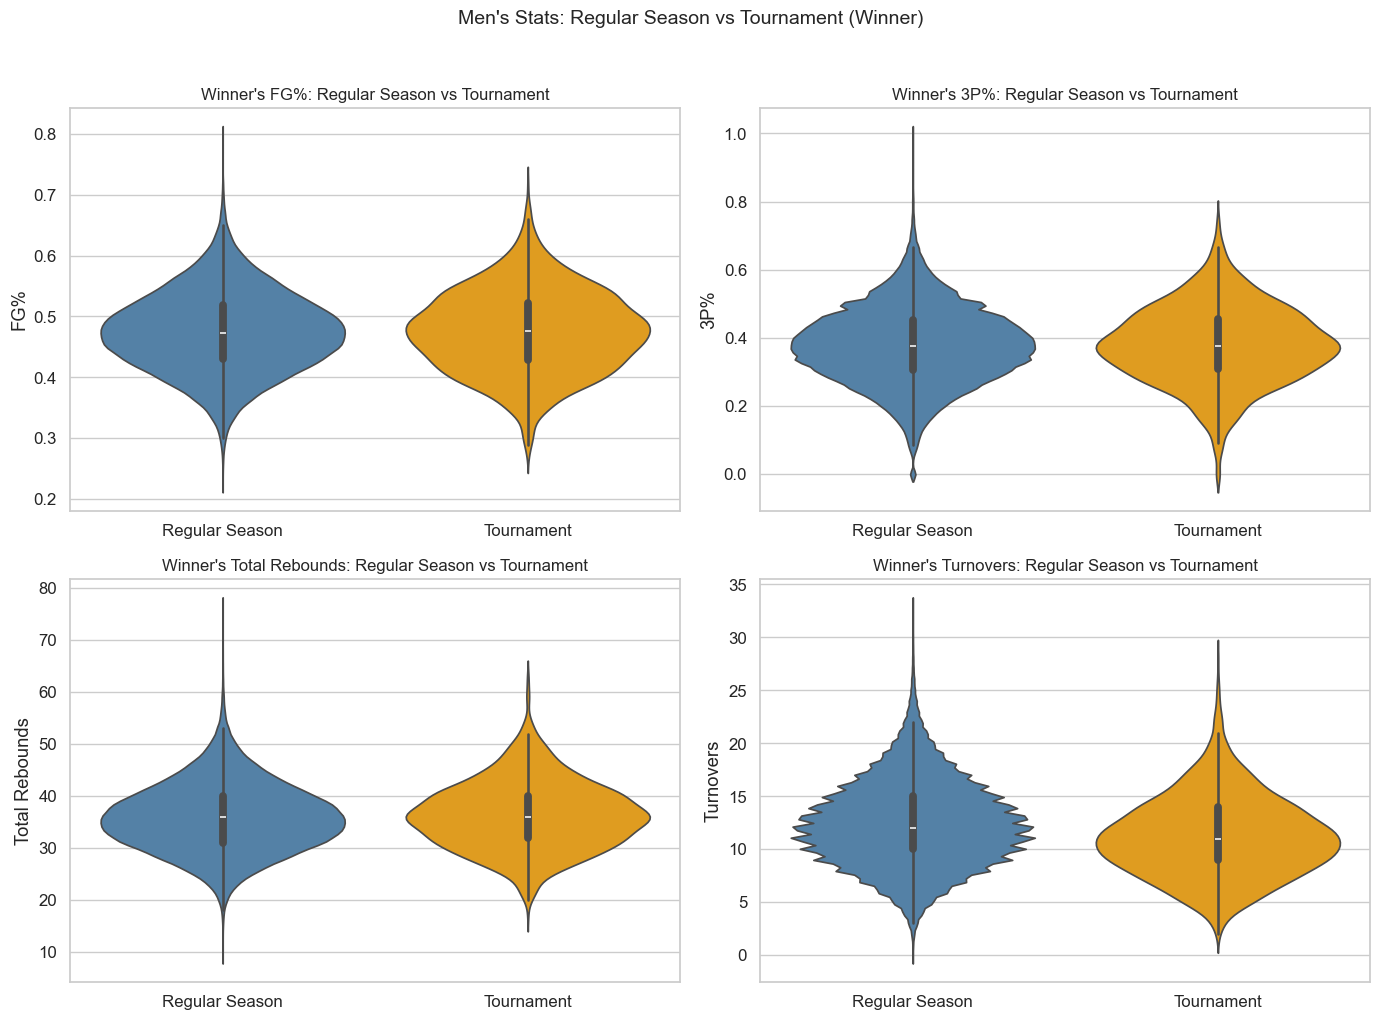

In [27]:
# Regular season vs Tournament stat distributions (violin plots)
key_stats = ['WFGPct', 'WFG3Pct', 'WTotalReb', 'WTO']
stat_names = ['FG%', '3P%', 'Total Rebounds', 'Turnovers']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, (stat, name) in enumerate(zip(key_stats, stat_names)):
    ax = axes[idx // 2, idx % 2]
    rs_vals = m_rs_detail[stat].dropna()
    tn_vals = m_tourney_detail[stat].dropna()
    
    plot_data = pd.DataFrame({
        'Value': pd.concat([rs_vals, tn_vals]),
        'Type': ['Regular Season'] * len(rs_vals) + ['Tournament'] * len(tn_vals)
    })
    sns.violinplot(data=plot_data, x='Type', y='Value', ax=ax, palette=['steelblue', 'orange'])
    ax.set_title(f"Winner's {name}: Regular Season vs Tournament", fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel(name)

plt.suptitle("Men's Stats: Regular Season vs Tournament (Winner)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

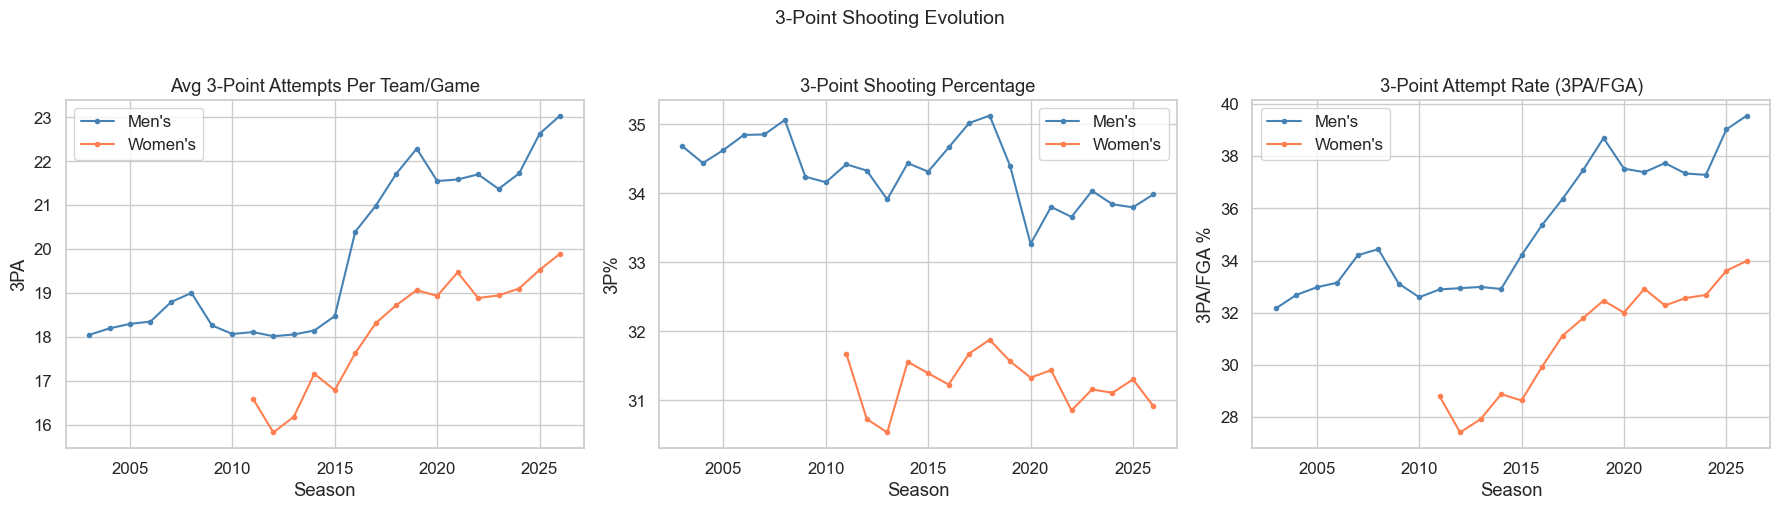

In [28]:
# 3-Point shooting deep dive
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for df, label, color in [(m_rs_detail, "Men's", 'steelblue'), (w_rs_detail, "Women's", 'coral')]:
    # Average 3PA per game
    avg_3pa = df.groupby('Season').apply(lambda x: (x['WFGA3'].mean() + x['LFGA3'].mean()) / 2)
    axes[0].plot(avg_3pa.index, avg_3pa.values, marker='o', markersize=3, label=label, color=color)
    
    # Average 3P%
    avg_3pct = df.groupby('Season').apply(
        lambda x: (x['WFGM3'].sum() + x['LFGM3'].sum()) / (x['WFGA3'].sum() + x['LFGA3'].sum())
    )
    axes[1].plot(avg_3pct.index, avg_3pct.values * 100, marker='o', markersize=3, label=label, color=color)
    
    # 3PA / FGA ratio
    ratio = df.groupby('Season').apply(
        lambda x: (x['WFGA3'].sum() + x['LFGA3'].sum()) / (x['WFGA'].sum() + x['LFGA'].sum())
    )
    axes[2].plot(ratio.index, ratio.values * 100, marker='o', markersize=3, label=label, color=color)

axes[0].set_title('Avg 3-Point Attempts Per Team/Game')
axes[0].set_xlabel('Season'); axes[0].set_ylabel('3PA')
axes[0].legend()

axes[1].set_title('3-Point Shooting Percentage')
axes[1].set_xlabel('Season'); axes[1].set_ylabel('3P%')
axes[1].legend()

axes[2].set_title('3-Point Attempt Rate (3PA/FGA)')
axes[2].set_xlabel('Season'); axes[2].set_ylabel('3PA/FGA %')
axes[2].legend()

plt.suptitle('3-Point Shooting Evolution', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

<a id='7'></a>
## 7. Seed Analysis

In [29]:
# Merge seeds with tournament results
def build_tourney_with_seeds(tourney_compact, seeds):
    """Add seed info to tournament games."""
    tc = tourney_compact.merge(
        seeds[['Season', 'TeamID', 'SeedNum']].rename(columns={'TeamID': 'WTeamID', 'SeedNum': 'WSeed'}),
        on=['Season', 'WTeamID'], how='left'
    ).merge(
        seeds[['Season', 'TeamID', 'SeedNum']].rename(columns={'TeamID': 'LTeamID', 'SeedNum': 'LSeed'}),
        on=['Season', 'LTeamID'], how='left'
    )
    return tc

m_tourney_seeds = build_tourney_with_seeds(m_tourney_compact, m_seeds)
w_tourney_seeds = build_tourney_with_seeds(w_tourney_compact, w_seeds)

print(f"Men's tourney games with seeds: {len(m_tourney_seeds)} (missing seeds: {m_tourney_seeds['WSeed'].isna().sum()})")
print(f"Women's tourney games with seeds: {len(w_tourney_seeds)} (missing seeds: {w_tourney_seeds['WSeed'].isna().sum()})")

Men's tourney games with seeds: 1449 (missing seeds: 0)
Women's tourney games with seeds: 898 (missing seeds: 0)


In [30]:
# 16x16 Seed matchup win probability heatmap (Men's)
import numpy as np

m_ts = m_tourney_seeds.dropna(subset=['WSeed', 'LSeed']).copy()
m_ts['WSeed'] = m_ts['WSeed'].astype(int)
m_ts['LSeed'] = m_ts['LSeed'].astype(int)

results = []
for _, row in m_ts.iterrows():
    better = min(row['WSeed'], row['LSeed'])
    worse  = max(row['WSeed'], row['LSeed'])
    results.append({'BetterSeed': better, 'WorseSeed': worse, 'BetterWon': int(row['WSeed'] == better)})

results_df = pd.DataFrame(results)
matchup_matrix = results_df.groupby(['BetterSeed', 'WorseSeed']).agg(
    WinRate=('BetterWon', 'mean'),
    Count=('BetterWon', 'size')
).reset_index()

win_pivot   = matchup_matrix.pivot(index='BetterSeed', columns='WorseSeed', values='WinRate')
count_pivot = matchup_matrix.pivot(index='BetterSeed', columns='WorseSeed', values='Count')

# Build annotation as object array to avoid dtype conflict
annot = np.full(win_pivot.shape, '', dtype=object)
for ri, i in enumerate(win_pivot.index):
    for ci, j in enumerate(win_pivot.columns):
        v = win_pivot.loc[i, j]
        if pd.notna(v):
            cnt = count_pivot.loc[i, j]
            annot[ri, ci] = f'{v:.0%} (n={int(cnt)})'

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(win_pivot, annot=annot, fmt='', cmap='RdYlGn', center=0.5,
            linewidths=0.5, ax=ax, vmin=0, vmax=1,
            cbar_kws={'label': 'Higher Seed Win Probability'})
ax.set_title("Men's NCAA Tournament: Higher Seed Win Probability by Matchup", fontsize=14)
ax.set_xlabel('Lower Seed (Weaker)')
ax.set_ylabel('Higher Seed (Stronger)')
plt.tight_layout()
plt.show()


SyntaxError: unterminated f-string literal (detected at line 30) (3117018274.py, line 30)

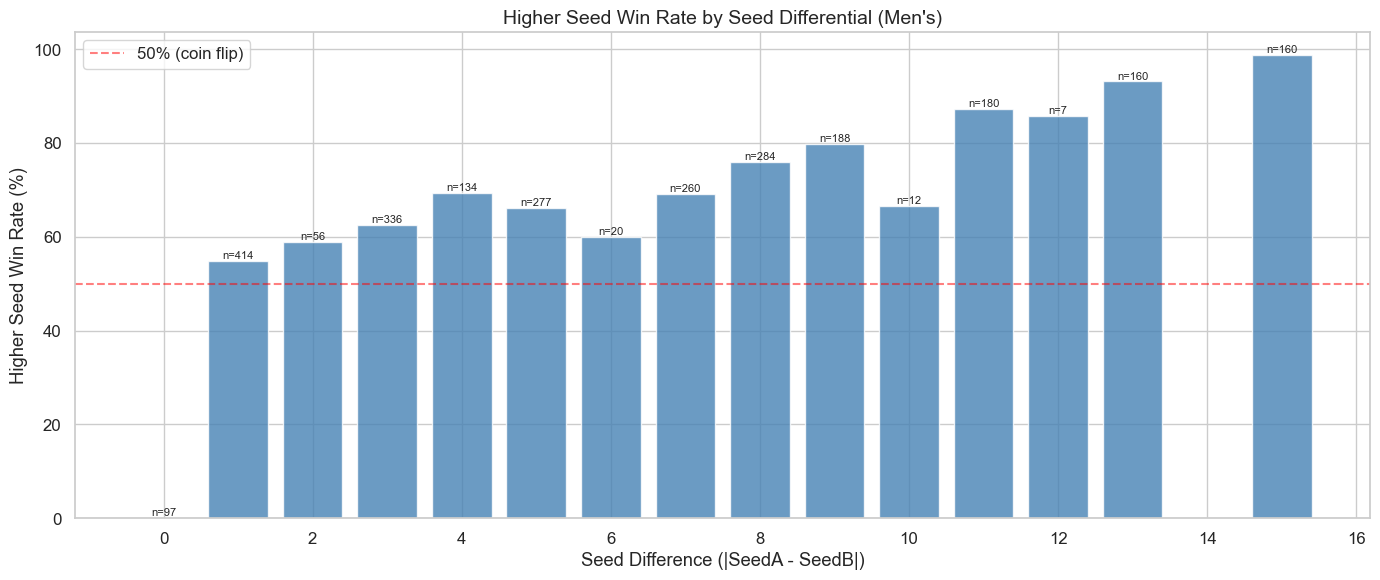

In [ ]:
# Upset frequency by seed differential
m_ts['SeedDiff'] = abs(m_ts['WSeed'] - m_ts['LSeed'])
m_ts['HigherSeedWon'] = m_ts['WSeed'] < m_ts['LSeed']

upset_by_diff = m_ts.groupby('SeedDiff').agg(
    HigherSeedWinRate=('HigherSeedWon', 'mean'),
    Count=('HigherSeedWon', 'size')
).reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(upset_by_diff['SeedDiff'], upset_by_diff['HigherSeedWinRate'] * 100,
              color='steelblue', alpha=0.8)
ax.axhline(y=50, color='red', linestyle='--', alpha=0.5, label='50% (coin flip)')

for bar, cnt in zip(bars, upset_by_diff['Count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'n={cnt}', ha='center', fontsize=8)

ax.set_title("Higher Seed Win Rate by Seed Differential (Men's)", fontsize=14)
ax.set_xlabel('Seed Difference (|SeedA - SeedB|)')
ax.set_ylabel('Higher Seed Win Rate (%)')
ax.legend()
plt.tight_layout()
plt.show()

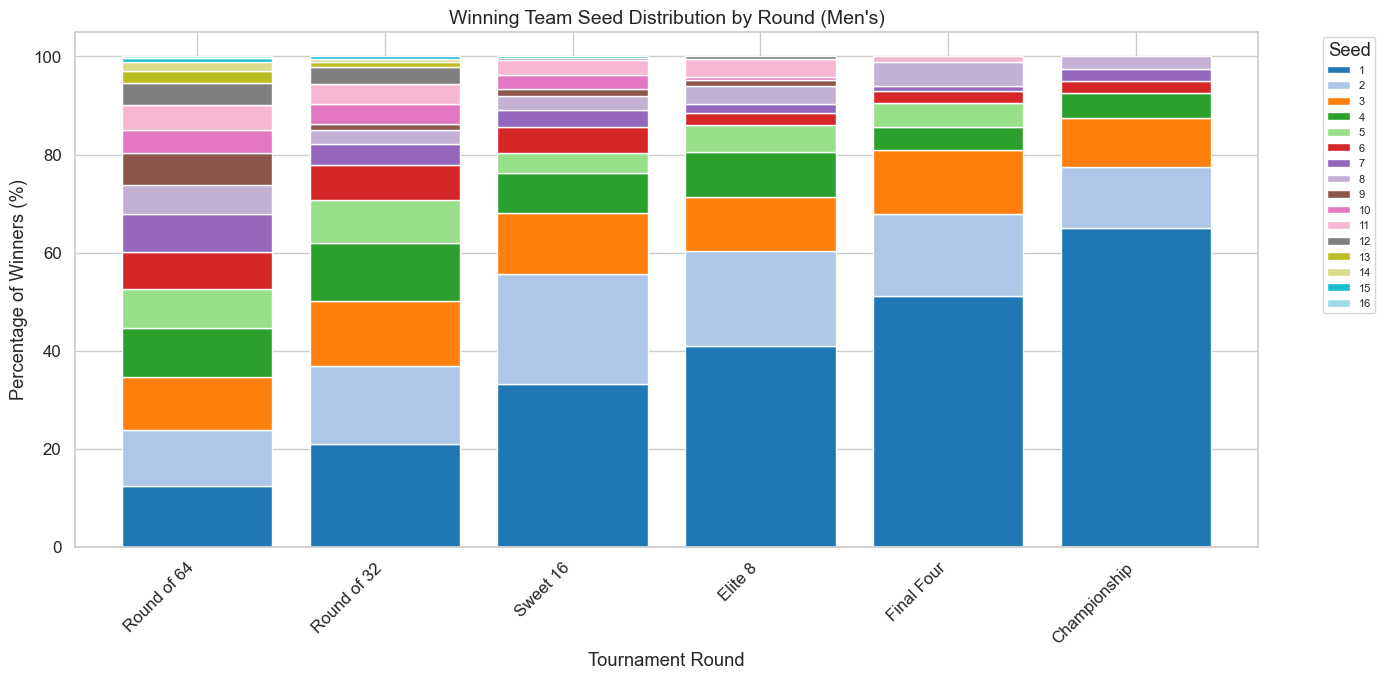

In [ ]:
# Seed performance by tournament round
def map_daynum_to_round(day):
    if day <= 135: return 'Play-In'
    elif day <= 137: return 'Round of 64'
    elif day <= 139: return 'Round of 32'
    elif day <= 144: return 'Sweet 16'
    elif day <= 146: return 'Elite 8'
    elif day <= 152: return 'Final Four'
    else: return 'Championship'

m_ts['Round'] = m_ts['DayNum'].apply(map_daynum_to_round)

# Count winning seeds per round
round_order = ['Round of 64', 'Round of 32', 'Sweet 16', 'Elite 8', 'Final Four', 'Championship']
m_ts_rounds = m_ts[m_ts['Round'].isin(round_order)].copy()

seed_by_round = m_ts_rounds.groupby(['Round', 'WSeed']).size().unstack(fill_value=0)
seed_by_round = seed_by_round.reindex(round_order)

# Normalize to percentages
seed_by_round_pct = seed_by_round.div(seed_by_round.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 7))
seed_by_round_pct.plot(kind='bar', stacked=True, ax=ax, colormap='tab20', width=0.8)
ax.set_title("Winning Team Seed Distribution by Round (Men's)", fontsize=14)
ax.set_xlabel('Tournament Round')
ax.set_ylabel('Percentage of Winners (%)')
ax.legend(title='Seed', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

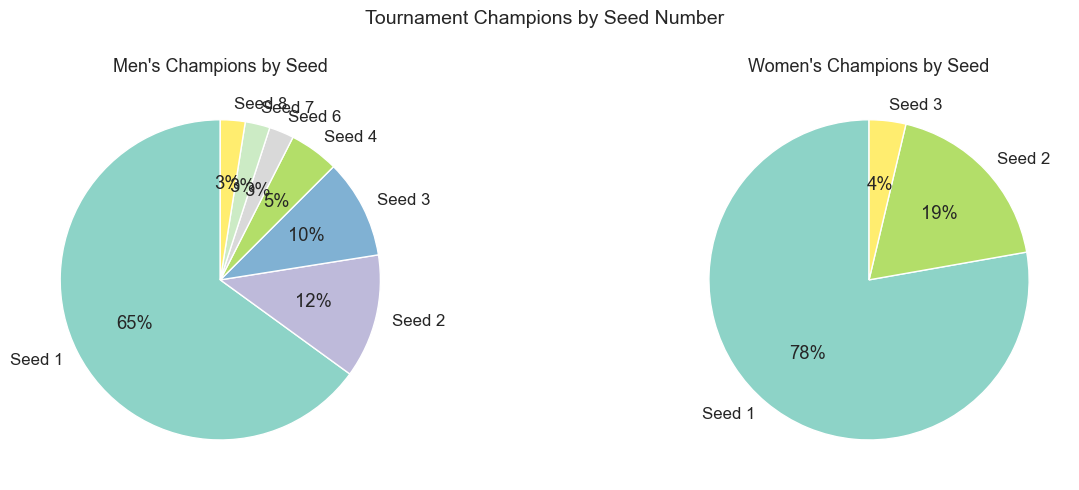

In [ ]:
# Historical champions by seed
champ_games_m = m_ts[m_ts['Round'] == 'Championship'].copy()
champ_seeds = champ_games_m['WSeed'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Men's champions
colors = plt.cm.Set3(np.linspace(0, 1, len(champ_seeds)))
axes[0].pie(champ_seeds.values, labels=[f'Seed {int(s)}' for s in champ_seeds.index],
            autopct='%1.0f%%', colors=colors, startangle=90)
axes[0].set_title("Men's Champions by Seed", fontsize=13)

# Women's champions
w_ts = w_tourney_seeds.dropna(subset=['WSeed', 'LSeed']).copy()
w_ts['WSeed'] = w_ts['WSeed'].astype(int)
w_ts['LSeed'] = w_ts['LSeed'].astype(int)
w_ts['Round'] = w_ts['DayNum'].apply(map_daynum_to_round)
w_champ = w_ts[w_ts['DayNum'] == w_ts.groupby('Season')['DayNum'].transform('max')]
w_champ_seeds = w_champ['WSeed'].value_counts().sort_index()

colors_w = plt.cm.Set3(np.linspace(0, 1, len(w_champ_seeds)))
axes[1].pie(w_champ_seeds.values, labels=[f'Seed {int(s)}' for s in w_champ_seeds.index],
            autopct='%1.0f%%', colors=colors_w, startangle=90)
axes[1].set_title("Women's Champions by Seed", fontsize=13)

plt.suptitle('Tournament Champions by Seed Number', fontsize=14)
plt.tight_layout()
plt.show()

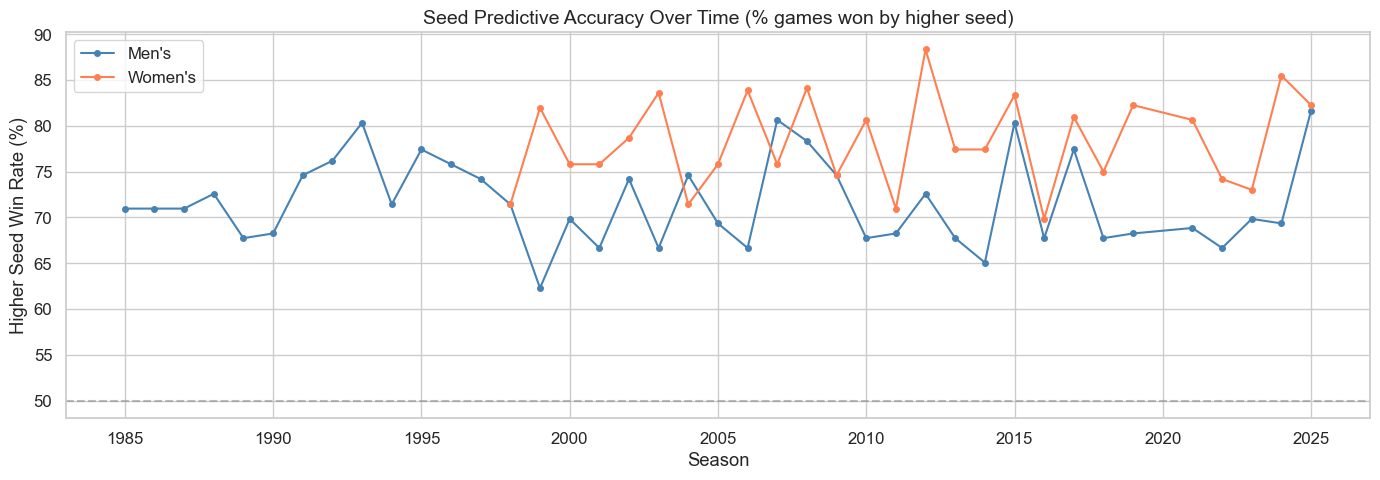

In [ ]:
# Seed predictive accuracy over time
fig, ax = plt.subplots(figsize=(14, 5))

for ts_df, label, color in [(m_ts, "Men's", 'steelblue'), (w_ts, "Women's", 'coral')]:
    ts_nontie = ts_df[ts_df['WSeed'] != ts_df['LSeed']].copy()
    ts_nontie['HigherSeedWon'] = ts_nontie['WSeed'] < ts_nontie['LSeed']
    acc = ts_nontie.groupby('Season')['HigherSeedWon'].mean()
    ax.plot(acc.index, acc.values * 100, marker='o', markersize=4, label=label, color=color)

ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Seed Predictive Accuracy Over Time (% games won by higher seed)', fontsize=14)
ax.set_xlabel('Season')
ax.set_ylabel('Higher Seed Win Rate (%)')
ax.legend()
plt.tight_layout()
plt.show()

<a id='8'></a>
## 8. Conference Analysis

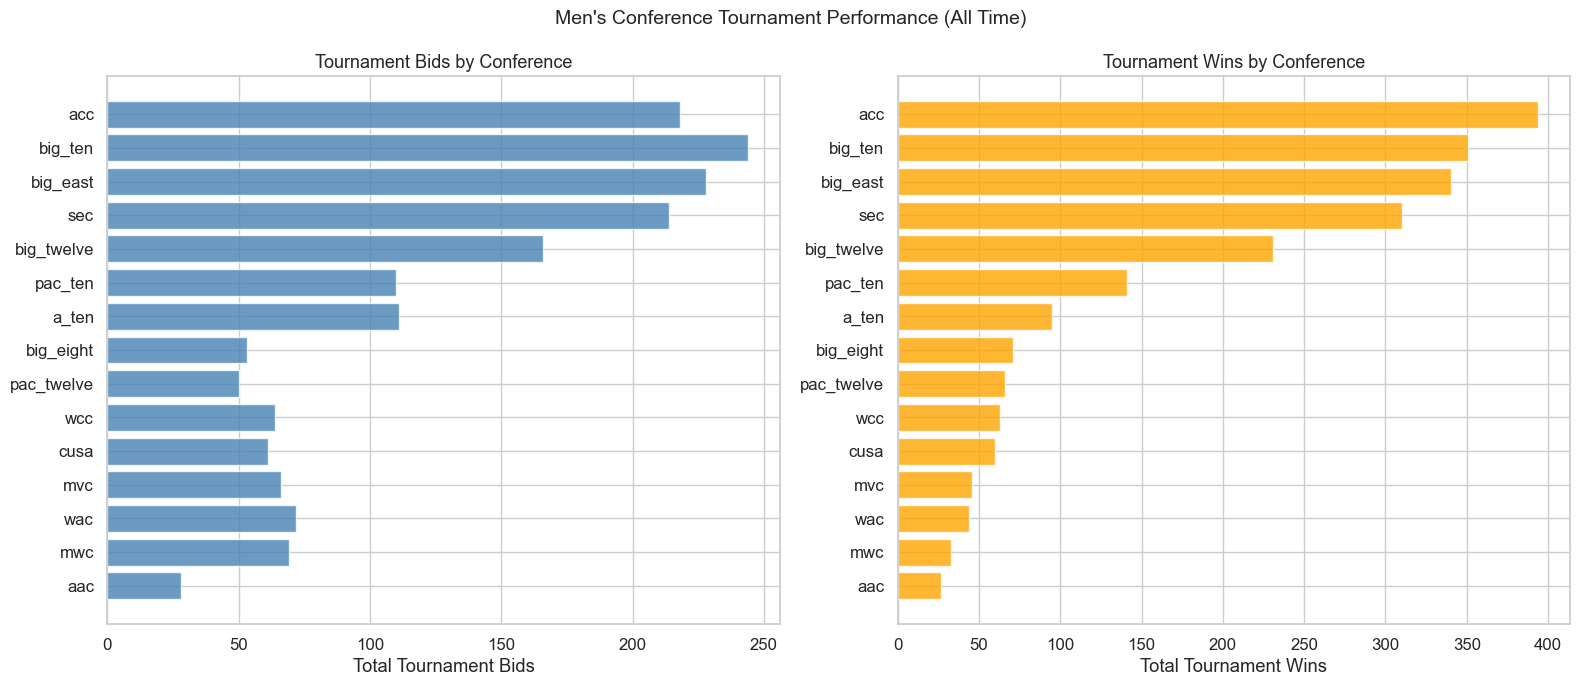


Top 15 Conferences by Tournament Wins:


,ConfAbbrev,Description,TotalBids,TotalTourneyWins,WinRate
3,acc,Atlantic Coast Conference,218,394.0,1.807
10,big_ten,Big Ten Conference,244,351.0,1.439
6,big_east,Big East Conference,228,340.0,1.491
39,sec,Southeastern Conference,214,310.0,1.449
11,big_twelve,Big 12 Conference,166,231.0,1.392
35,pac_ten,Pacific-10 Conference,110,141.0,1.282
1,a_ten,Atlantic 10 Conference,111,95.0,0.856
7,big_eight,Big Eight Conference,53,71.0,1.340
36,pac_twelve,Pacific-12 Conference,50,66.0,1.320
47,wcc,West Coast Conference,64,63.0,0.984


In [ ]:
# Conference tournament bids and success
m_seed_conf = m_seeds.merge(m_conferences, on=['Season', 'TeamID'], how='left')
conf_bids = m_seed_conf.groupby('ConfAbbrev').size().reset_index(name='TotalBids')

# Tournament wins by conference
tourney_w_conf = m_tourney_compact.merge(
    m_conferences.rename(columns={'TeamID': 'WTeamID', 'ConfAbbrev': 'WConf'}),
    on=['Season', 'WTeamID'], how='left'
)
conf_wins = tourney_w_conf.groupby('WConf').size().reset_index(name='TotalTourneyWins')
conf_wins.rename(columns={'WConf': 'ConfAbbrev'}, inplace=True)

conf_summary = conf_bids.merge(conf_wins, on='ConfAbbrev', how='left').fillna(0)
conf_summary['WinRate'] = conf_summary['TotalTourneyWins'] / conf_summary['TotalBids']
conf_summary = conf_summary.merge(conferences, on='ConfAbbrev', how='left')
conf_summary = conf_summary.sort_values('TotalTourneyWins', ascending=False)

# Top 15 conferences
top15_conf = conf_summary.head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Bids
axes[0].barh(range(len(top15_conf)), top15_conf['TotalBids'].values, color='steelblue', alpha=0.8)
axes[0].set_yticks(range(len(top15_conf)))
axes[0].set_yticklabels(top15_conf['ConfAbbrev'].values)
axes[0].invert_yaxis()
axes[0].set_xlabel('Total Tournament Bids')
axes[0].set_title('Tournament Bids by Conference', fontsize=13)

# Wins
axes[1].barh(range(len(top15_conf)), top15_conf['TotalTourneyWins'].values, color='orange', alpha=0.8)
axes[1].set_yticks(range(len(top15_conf)))
axes[1].set_yticklabels(top15_conf['ConfAbbrev'].values)
axes[1].invert_yaxis()
axes[1].set_xlabel('Total Tournament Wins')
axes[1].set_title('Tournament Wins by Conference', fontsize=13)

plt.suptitle("Men's Conference Tournament Performance (All Time)", fontsize=14)
plt.tight_layout()
plt.show()

print('\nTop 15 Conferences by Tournament Wins:')
display(top15_conf[['ConfAbbrev', 'Description', 'TotalBids', 'TotalTourneyWins', 'WinRate']].round(3))

In [ ]:
# Conference size over time (top conferences)
power_confs = ['acc', 'big_ten', 'big_twelve', 'sec', 'big_east', 'pac_twelve', 'aac']

conf_size_by_year = m_conferences.groupby(['Season', 'ConfAbbrev']).size().reset_index(name='NumTeams')
power_data = conf_size_by_year[conf_size_by_year['ConfAbbrev'].isin(power_confs)]

fig = px.line(power_data, x='Season', y='NumTeams', color='ConfAbbrev',
              title="Power Conference Size Over Time (Men's)",
              labels={'NumTeams': 'Number of Teams', 'ConfAbbrev': 'Conference'})
fig.update_layout(width=900, height=500)
fig.show()

<a id='9'></a>
## 9. Rankings Analysis (Massey Ordinals)

In [ ]:
# Rankings overview
print(f"Total rows: {len(massey):,}")
print(f"Unique ranking systems: {massey['SystemName'].nunique()}")
print(f"Seasons: {massey['Season'].min()}-{massey['Season'].max()}")
print(f"\nRanking days per season:")
print(massey.groupby('Season')['RankingDayNum'].nunique().describe())

# Systems available per season
systems_per_season = massey.groupby('Season')['SystemName'].nunique()
print(f"\nSystems per season (recent):")
print(systems_per_season.tail(10))

Total rows: 5,819,228
Unique ranking systems: 196
Seasons: 2003-2026

Ranking days per season:
count    24.000000
mean     35.500000
std      20.466303
min      16.000000
25%      18.000000
50%      19.000000
75%      54.000000
max      69.000000
Name: RankingDayNum, dtype: float64

Systems per season (recent):
Season
2017    76
2018    69
2019    70
2020    68
2021    57
2022    66
2023    68
2024    63
2025    58
2026    58
Name: SystemName, dtype: int64


In [ ]:
# Get pre-tournament rankings (last ranking before tournament, DayNum <= 133)
pre_tourney = massey[massey['RankingDayNum'] <= 133].copy()
last_rankings = pre_tourney.sort_values('RankingDayNum').groupby(
    ['Season', 'SystemName', 'TeamID']
).tail(1).reset_index(drop=True)

print(f"Pre-tournament rankings: {len(last_rankings):,} rows")
print(f"Unique systems: {last_rankings['SystemName'].nunique()}")

Pre-tournament rankings: 457,958 rows
Unique systems: 196


Evaluating ranking systems: 100%|██████████| 196/196 [00:03<00:00, 49.65it/s]


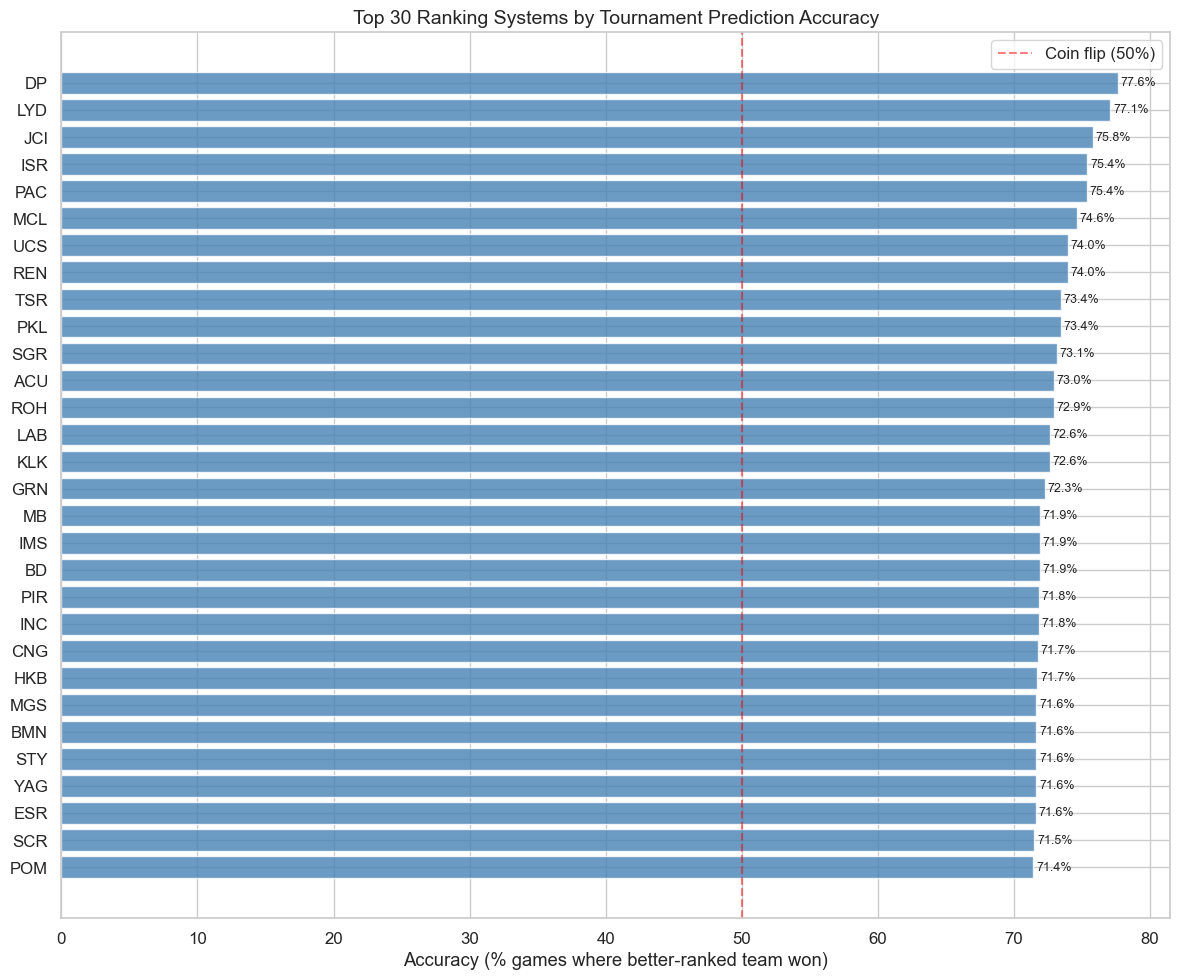


Top 10 most predictive ranking systems:


,System,Accuracy,GamesEvaluated
81,DP,0.776119,134
104,LYD,0.770833,192
162,JCI,0.757812,128
148,ISR,0.753906,256
43,PAC,0.753731,134
179,MCL,0.746269,134
101,UCS,0.739583,192
165,REN,0.739583,192
28,TSR,0.734375,384
167,PKL,0.734375,128


In [ ]:
# Which ranking systems best predict tournament outcomes
from tqdm import tqdm

def evaluate_ranking_system(tourney_df, rankings_df, system_name):
    sys_ranks = rankings_df[rankings_df['SystemName'] == system_name]
    
    merged = tourney_df.merge(
        sys_ranks[['Season', 'TeamID', 'OrdinalRank']].rename(
            columns={'TeamID': 'WTeamID', 'OrdinalRank': 'WRank'}),
        on=['Season', 'WTeamID'], how='inner'
    ).merge(
        sys_ranks[['Season', 'TeamID', 'OrdinalRank']].rename(
            columns={'TeamID': 'LTeamID', 'OrdinalRank': 'LRank'}),
        on=['Season', 'LTeamID'], how='inner'
    )
    
    if len(merged) == 0:
        return np.nan, 0
    
    # Lower rank = better team. Winner should have lower rank.
    merged['Correct'] = merged['WRank'] < merged['LRank']
    return merged['Correct'].mean(), len(merged)

systems = last_rankings['SystemName'].unique()
system_results = []

for sys_name in tqdm(systems, desc='Evaluating ranking systems'):
    acc, count = evaluate_ranking_system(m_tourney_compact, last_rankings, sys_name)
    system_results.append({'System': sys_name, 'Accuracy': acc, 'GamesEvaluated': count})

sys_eval = pd.DataFrame(system_results).dropna().sort_values('Accuracy', ascending=False)

# Show top 30
top30 = sys_eval[sys_eval['GamesEvaluated'] >= 100].head(30)

fig, ax = plt.subplots(figsize=(12, 10))
bars = ax.barh(range(len(top30)), top30['Accuracy'].values * 100, color='steelblue', alpha=0.8)
ax.set_yticks(range(len(top30)))
ax.set_yticklabels(top30['System'].values)
ax.invert_yaxis()
ax.set_xlabel('Accuracy (% games where better-ranked team won)')
ax.set_title('Top 30 Ranking Systems by Tournament Prediction Accuracy', fontsize=14)
ax.axvline(x=50, color='red', linestyle='--', alpha=0.5, label='Coin flip (50%)')

for bar, val in zip(bars, top30['Accuracy'].values):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val*100:.1f}%', va='center', fontsize=9)

ax.legend()
plt.tight_layout()
plt.show()

print('\nTop 10 most predictive ranking systems:')
display(top30.head(10))

C:\Users\Kacper\AppData\Local\Temp\ipykernel_5276\3172240900.py:29: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\Kacper\AppData\Local\Temp\ipykernel_5276\3172240900.py:29: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\Kacper\AppData\Local\Temp\ipykernel_5276\3172240900.py:29: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\Kacper\AppData\Local\Temp\ipykernel_5276\3172240900.py:29: FutureWarning:

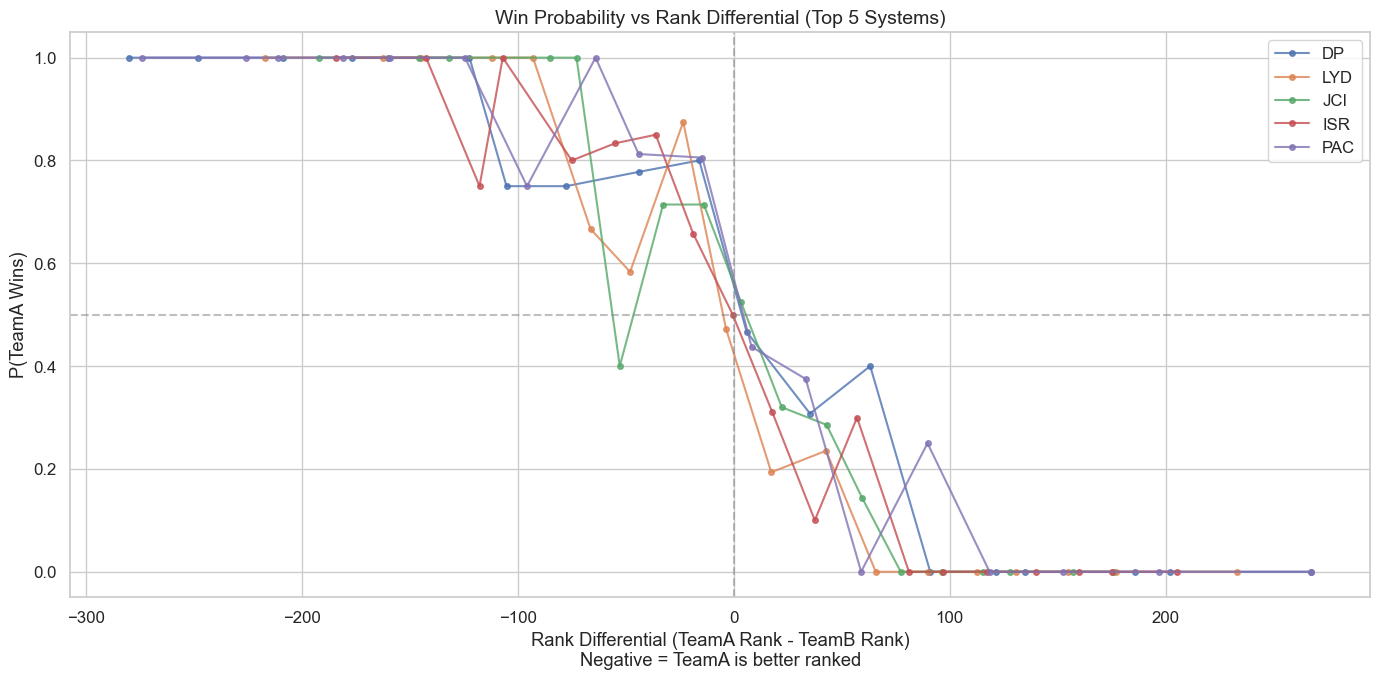

In [ ]:
# Rank differential vs win probability calibration (top 5 systems)
top5_systems = top30.head(5)['System'].tolist()

fig, ax = plt.subplots(figsize=(14, 7))

for sys_name in top5_systems:
    sys_ranks = last_rankings[last_rankings['SystemName'] == sys_name]
    
    merged = m_tourney_compact.merge(
        sys_ranks[['Season', 'TeamID', 'OrdinalRank']].rename(
            columns={'TeamID': 'WTeamID', 'OrdinalRank': 'WRank'}),
        on=['Season', 'WTeamID'], how='inner'
    ).merge(
        sys_ranks[['Season', 'TeamID', 'OrdinalRank']].rename(
            columns={'TeamID': 'LTeamID', 'OrdinalRank': 'LRank'}),
        on=['Season', 'LTeamID'], how='inner'
    )
    
    # Normalize: TeamA is always the lower-ID team (like submission format)
    merged['TeamA'] = merged[['WTeamID', 'LTeamID']].min(axis=1)
    merged['TeamB'] = merged[['WTeamID', 'LTeamID']].max(axis=1)
    merged['RankA'] = merged.apply(lambda r: r['WRank'] if r['WTeamID'] == r['TeamA'] else r['LRank'], axis=1)
    merged['RankB'] = merged.apply(lambda r: r['WRank'] if r['WTeamID'] == r['TeamB'] else r['LRank'], axis=1)
    merged['RankDiff'] = merged['RankA'] - merged['RankB']  # negative = A is better
    merged['AWon'] = (merged['WTeamID'] == merged['TeamA']).astype(int)
    
    # Bin by rank differential
    merged['RankDiffBin'] = pd.cut(merged['RankDiff'], bins=20)
    calibration = merged.groupby('RankDiffBin').agg(
        WinRate=('AWon', 'mean'),
        MidPoint=('RankDiff', 'mean'),
        Count=('AWon', 'size')
    ).dropna()
    
    ax.plot(calibration['MidPoint'], calibration['WinRate'], marker='o', 
            markersize=4, label=sys_name, alpha=0.8)

ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Win Probability vs Rank Differential (Top 5 Systems)', fontsize=14)
ax.set_xlabel('Rank Differential (TeamA Rank - TeamB Rank)\nNegative = TeamA is better ranked')
ax.set_ylabel('P(TeamA Wins)')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Composite ranking: average across all systems
composite = last_rankings.groupby(['Season', 'TeamID'])['OrdinalRank'].mean().reset_index()
composite.rename(columns={'OrdinalRank': 'CompositeRank'}, inplace=True)

# Evaluate composite
comp_merged = m_tourney_compact.merge(
    composite.rename(columns={'TeamID': 'WTeamID', 'CompositeRank': 'WRank'}),
    on=['Season', 'WTeamID'], how='inner'
).merge(
    composite.rename(columns={'TeamID': 'LTeamID', 'CompositeRank': 'LRank'}),
    on=['Season', 'LTeamID'], how='inner'
)

comp_acc = (comp_merged['WRank'] < comp_merged['LRank']).mean()
print(f"Composite ranking accuracy: {comp_acc:.1%} ({len(comp_merged)} games)")
print(f"Best individual system accuracy: {top30.iloc[0]['Accuracy']:.1%} ({top30.iloc[0]['System']})")

Composite ranking accuracy: 70.9% (1449 games)
Best individual system accuracy: 77.6% (DP)


In [ ]:
# Ranking volatility: how rankings evolve during a season for sample teams
sample_season = 2025
# Get top 10 teams by composite rank
top_teams_25 = composite[composite['Season'] == sample_season].nsmallest(10, 'CompositeRank')['TeamID'].tolist()

# Use a popular system (first of top 5)
sample_sys = top5_systems[0]
rank_evo = massey[(massey['Season'] == sample_season) & 
                   (massey['SystemName'] == sample_sys) &
                   (massey['TeamID'].isin(top_teams_25))].copy()
rank_evo = rank_evo.merge(m_teams[['TeamID', 'TeamName']], on='TeamID')

fig = px.line(rank_evo, x='RankingDayNum', y='OrdinalRank', color='TeamName',
              title=f'Ranking Evolution During {sample_season} Season ({sample_sys} system, Top 10 Teams)',
              labels={'RankingDayNum': 'Day Number', 'OrdinalRank': 'Rank (lower is better)'})
fig.update_yaxes(autorange='reversed')  # Lower rank = better, so invert
fig.update_layout(width=900, height=500)
fig.show()

<a id='10'></a>
## 10. Men's vs Women's Comparison

C:\Users\Kacper\AppData\Local\Temp\ipykernel_5276\2226169119.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\Kacper\AppData\Local\Temp\ipykernel_5276\2226169119.py:24: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




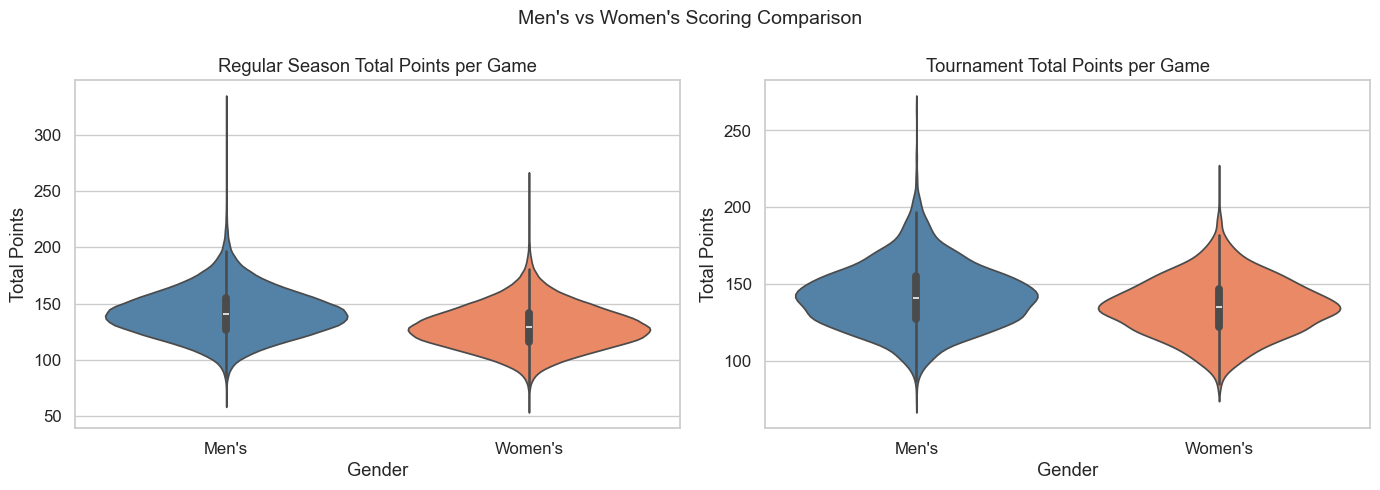

In [ ]:
# Scoring comparison: Men vs Women
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regular Season total points
m_total = m_rs_compact['WScore'] + m_rs_compact['LScore']
w_total = w_rs_compact['WScore'] + w_rs_compact['LScore']

plot_data_rs = pd.DataFrame({
    'Total Points': pd.concat([m_total, w_total]),
    'Gender': ["Men's"] * len(m_total) + ["Women's"] * len(w_total)
})
sns.violinplot(data=plot_data_rs, x='Gender', y='Total Points', ax=axes[0],
               palette=['steelblue', 'coral'])
axes[0].set_title('Regular Season Total Points per Game')

# Tournament total points
m_total_t = m_tourney_compact['WScore'] + m_tourney_compact['LScore']
w_total_t = w_tourney_compact['WScore'] + w_tourney_compact['LScore']

plot_data_tn = pd.DataFrame({
    'Total Points': pd.concat([m_total_t, w_total_t]),
    'Gender': ["Men's"] * len(m_total_t) + ["Women's"] * len(w_total_t)
})
sns.violinplot(data=plot_data_tn, x='Gender', y='Total Points', ax=axes[1],
               palette=['steelblue', 'coral'])
axes[1].set_title('Tournament Total Points per Game')

plt.suptitle("Men's vs Women's Scoring Comparison", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Competitiveness metrics comparison
metrics = []
for df, t_df, label in [
    (m_rs_compact, m_tourney_compact, "Men's"),
    (w_rs_compact, w_tourney_compact, "Women's")
]:
    rs_margin = df['WScore'] - df['LScore']
    tn_margin = t_df['WScore'] - t_df['LScore']
    
    ha_games = df[df['WLoc'].isin(['H', 'A'])]
    home_adv = (ha_games['WLoc'] == 'H').mean() * 100
    
    metrics.append({
        'Gender': label,
        'RS Avg Margin': rs_margin.mean(),
        'Tournament Avg Margin': tn_margin.mean(),
        'RS Margin Std': rs_margin.std(),
        'RS OT Rate %': (df['NumOT'] > 0).mean() * 100,
        'Tourney OT Rate %': (t_df['NumOT'] > 0).mean() * 100,
        'Home Win %': home_adv,
    })

comp_df = pd.DataFrame(metrics).set_index('Gender')
print("Competitiveness Comparison:")
display(comp_df.round(2))

Competitiveness Comparison:


,RS Avg Margin,Tournament Avg Margin,RS Margin Std,RS OT Rate %,Tourney OT Rate %,Home Win %
Gender,,,,,,
Men's,12.09,11.82,9.42,4.10,5.84,65.76
Women's,14.45,16.73,11.07,3.43,2.33,61.12


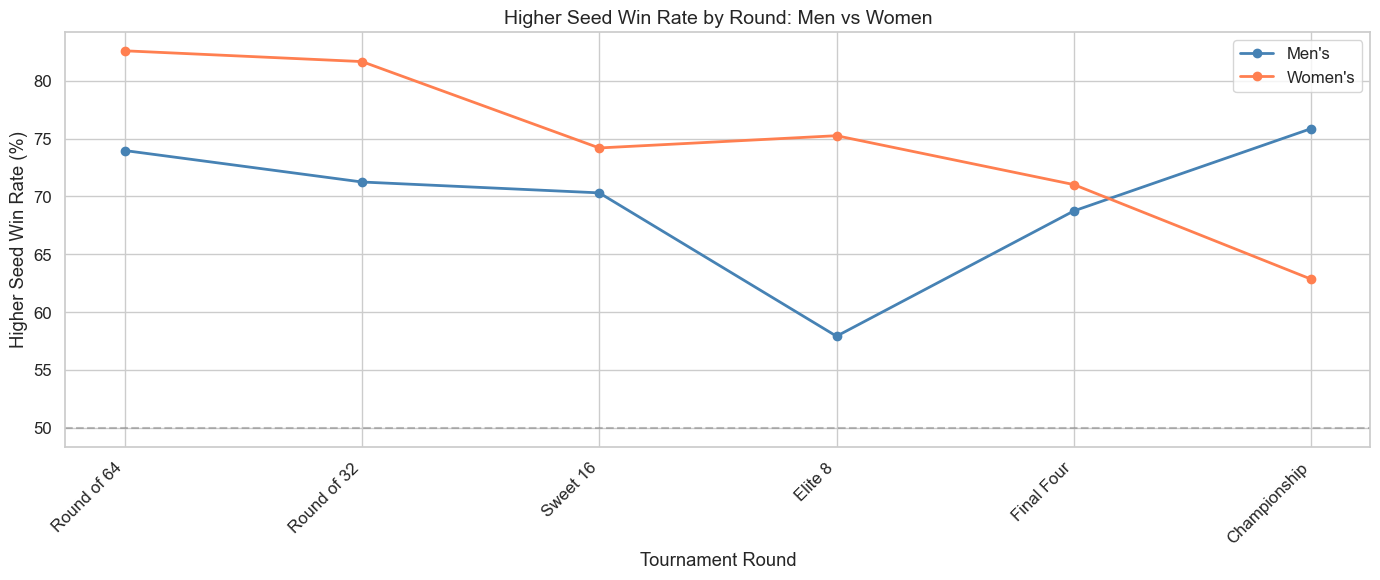

In [ ]:
# Seed predictiveness: Men vs Women
fig, ax = plt.subplots(figsize=(14, 6))

for ts_df, label, color in [(m_ts, "Men's", 'steelblue'), (w_ts, "Women's", 'coral')]:
    # For each round, compute higher seed win rate
    ts_nontie = ts_df[ts_df['WSeed'] != ts_df['LSeed']].copy()
    ts_nontie['HigherSeedWon'] = ts_nontie['WSeed'] < ts_nontie['LSeed']
    ts_nontie['Round'] = ts_nontie['DayNum'].apply(map_daynum_to_round)
    
    round_acc = ts_nontie.groupby('Round')['HigherSeedWon'].mean()
    round_acc = round_acc.reindex(round_order)
    ax.plot(round_acc.index, round_acc.values * 100, marker='o', markersize=6,
            label=label, color=color, linewidth=2)

ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Higher Seed Win Rate by Round: Men vs Women', fontsize=14)
ax.set_xlabel('Tournament Round')
ax.set_ylabel('Higher Seed Win Rate (%)')
ax.legend(fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

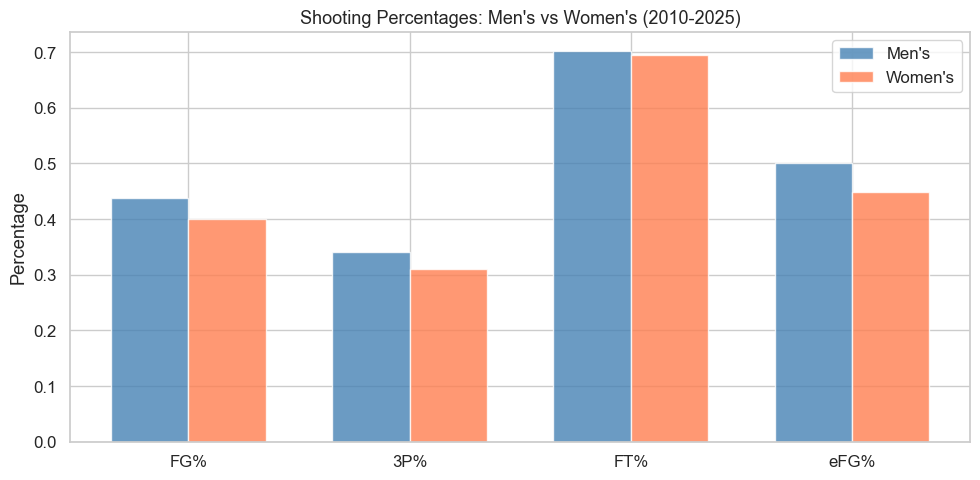

In [ ]:
# Box score comparison (2010+ where both have detailed data)
common_seasons = range(2010, 2026)

m_detail_common = m_rs_detail[m_rs_detail['Season'].isin(common_seasons)]
w_detail_common = w_rs_detail[w_rs_detail['Season'].isin(common_seasons)]

compare_stats = ['FGPct', 'FG3Pct', 'FTPct', 'eFGPct']
compare_labels = ['FG%', '3P%', 'FT%', 'eFG%']

m_avgs = {}
w_avgs = {}
for stat, label in zip(compare_stats, compare_labels):
    m_avgs[label] = (m_detail_common[f'W{stat}'].mean() + m_detail_common[f'L{stat}'].mean()) / 2
    w_avgs[label] = (w_detail_common[f'W{stat}'].mean() + w_detail_common[f'L{stat}'].mean()) / 2

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(compare_labels))
width = 0.35

ax.bar(x - width/2, [m_avgs[l] for l in compare_labels], width, label="Men's", color='steelblue', alpha=0.8)
ax.bar(x + width/2, [w_avgs[l] for l in compare_labels], width, label="Women's", color='coral', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(compare_labels)
ax.set_ylabel('Percentage')
ax.set_title("Shooting Percentages: Men's vs Women's (2010-2025)", fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

<a id='11'></a>
## 11. Temporal Trends

C:\Users\Kacper\AppData\Local\Temp\ipykernel_5276\3150337378.py:5: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

C:\Users\Kacper\AppData\Local\Temp\ipykernel_5276\3150337378.py:5: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

C:\Users\Kacper\AppData\Local\Temp\ipykernel_5276\3150337378.py:16: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a 

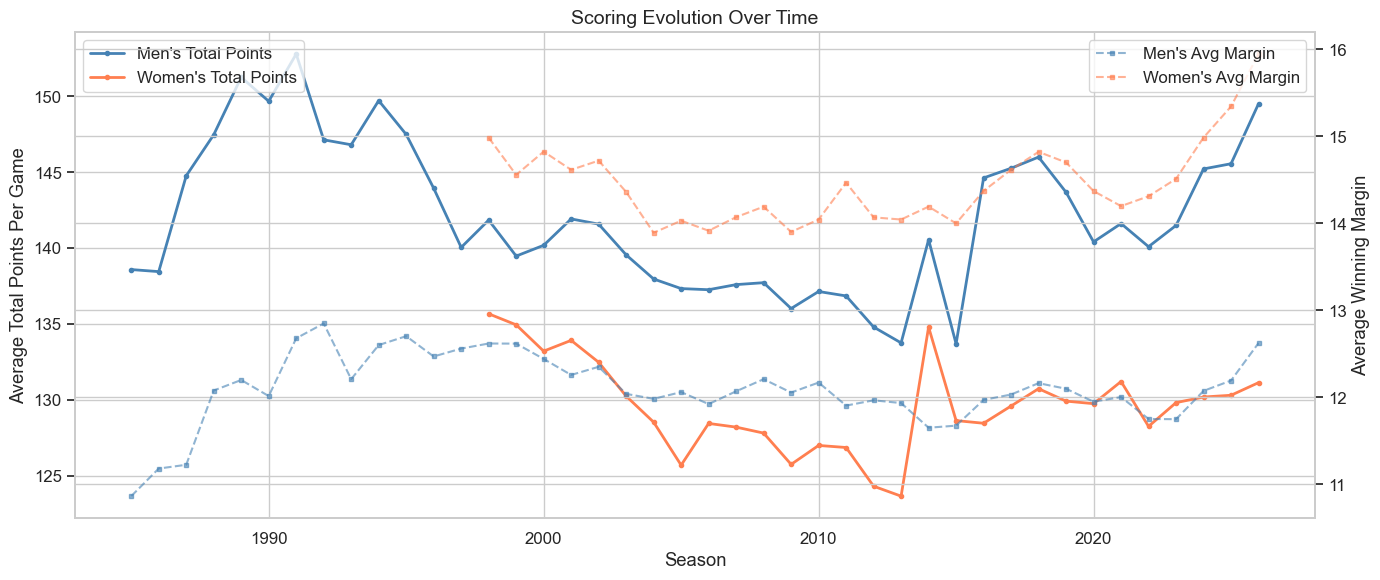

In [ ]:
# Scoring evolution: total points and margin over time
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=False)

for ax, df, label, color in [
    (axes[0], m_rs_compact, "Men's",   "steelblue"),
    (axes[1], w_rs_compact, "Women's", "coral"),
]:
    total_pts = df.groupby("Season").apply(lambda x: (x["WScore"] + x["LScore"]).mean())
    ax.plot(total_pts.index, total_pts.values, marker="o", markersize=3,
            label="Total Points", color=color, linewidth=2)
    ax.set_xlabel("Season")
    ax.set_ylabel("Average Total Points Per Game", color=color)
    ax.set_title(f"{label} Scoring Evolution", fontsize=13)

    ax2 = ax.twinx()
    margin = df.groupby("Season").apply(lambda x: (x["WScore"] - x["LScore"]).mean())
    ax2.plot(margin.index, margin.values, marker="s", markersize=3,
             label="Avg Margin", color=color, linestyle="--", alpha=0.6)
    ax2.set_ylabel("Average Winning Margin", color=color)

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.suptitle("Scoring Evolution Over Time", fontsize=15)
plt.tight_layout()
plt.show()


C:\Users\Kacper\AppData\Local\Temp\ipykernel_5276\3615122742.py:6: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

C:\Users\Kacper\AppData\Local\Temp\ipykernel_5276\3615122742.py:6: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



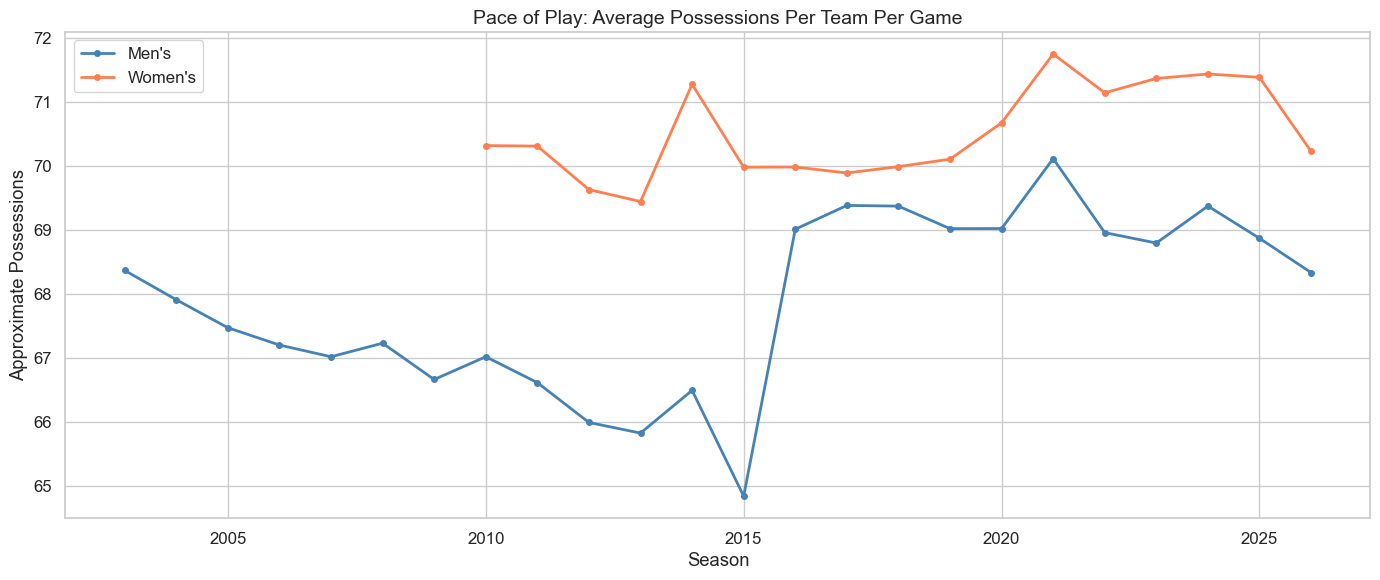

In [ ]:
# Pace of play: approximate possessions per game
fig, ax = plt.subplots(figsize=(14, 6))

for df, label, color in [(m_rs_detail, "Men's", 'steelblue'), (w_rs_detail, "Women's", 'coral')]:
    # Approximate possessions = FGA + 0.44*FTA + TO - OR
    pace = df.groupby('Season').apply(
        lambda x: (
            (x['WFGA'] + 0.44 * x['WFTA'] + x['WTO'] - x['WOR']).mean() +
            (x['LFGA'] + 0.44 * x['LFTA'] + x['LTO'] - x['LOR']).mean()
        ) / 2
    )
    ax.plot(pace.index, pace.values, marker='o', markersize=4, label=label, color=color, linewidth=2)

ax.set_title('Pace of Play: Average Possessions Per Team Per Game', fontsize=14)
ax.set_xlabel('Season')
ax.set_ylabel('Approximate Possessions')
ax.legend()
plt.tight_layout()
plt.show()

C:\Users\Kacper\AppData\Local\Temp\ipykernel_5276\3252918648.py:5: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

C:\Users\Kacper\AppData\Local\Temp\ipykernel_5276\3252918648.py:5: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



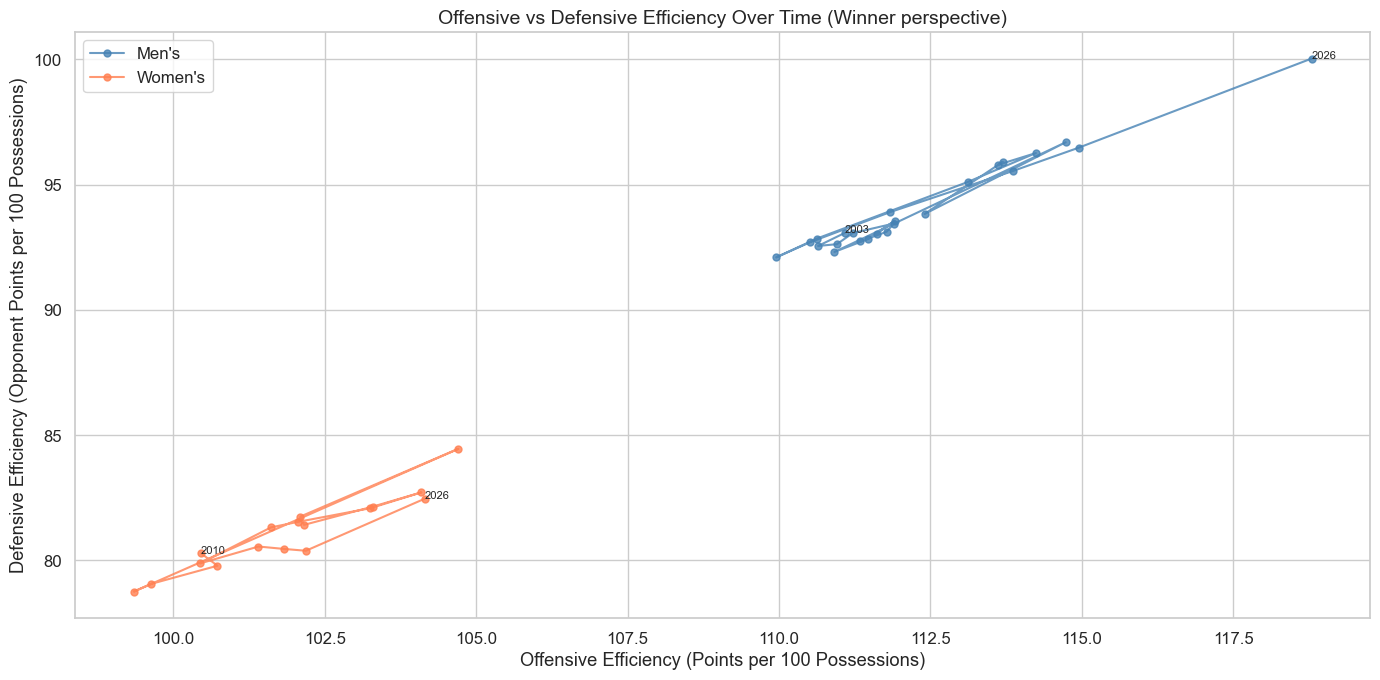

In [ ]:
# Offensive vs Defensive efficiency evolution
fig, ax = plt.subplots(figsize=(14, 7))

for df, rs_label, color in [(m_rs_detail, "Men's", 'steelblue'), (w_rs_detail, "Women's", 'coral')]:
    season_eff = df.groupby('Season').apply(
        lambda x: pd.Series({
            'OffEff': x['WScore'].sum() / (x['WFGA'].sum() + 0.44 * x['WFTA'].sum() + x['WTO'].sum() - x['WOR'].sum()) * 100,
            'DefEff': x['LScore'].sum() / (x['LFGA'].sum() + 0.44 * x['LFTA'].sum() + x['LTO'].sum() - x['LOR'].sum()) * 100,
        })
    ).reset_index()
    
    ax.plot(season_eff['OffEff'], season_eff['DefEff'], marker='o', markersize=5,
            label=rs_label, color=color, alpha=0.8)
    # Annotate first and last
    for i in [0, len(season_eff)-1]:
        ax.annotate(str(int(season_eff.iloc[i]['Season'])),
                   (season_eff.iloc[i]['OffEff'], season_eff.iloc[i]['DefEff']),
                   fontsize=8, ha='left')

ax.set_title('Offensive vs Defensive Efficiency Over Time (Winner perspective)', fontsize=14)
ax.set_xlabel('Offensive Efficiency (Points per 100 Possessions)')
ax.set_ylabel('Defensive Efficiency (Opponent Points per 100 Possessions)')
ax.legend()
plt.tight_layout()
plt.show()

C:\Users\Kacper\AppData\Local\Temp\ipykernel_5276\2825676149.py:7: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

C:\Users\Kacper\AppData\Local\Temp\ipykernel_5276\2825676149.py:7: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



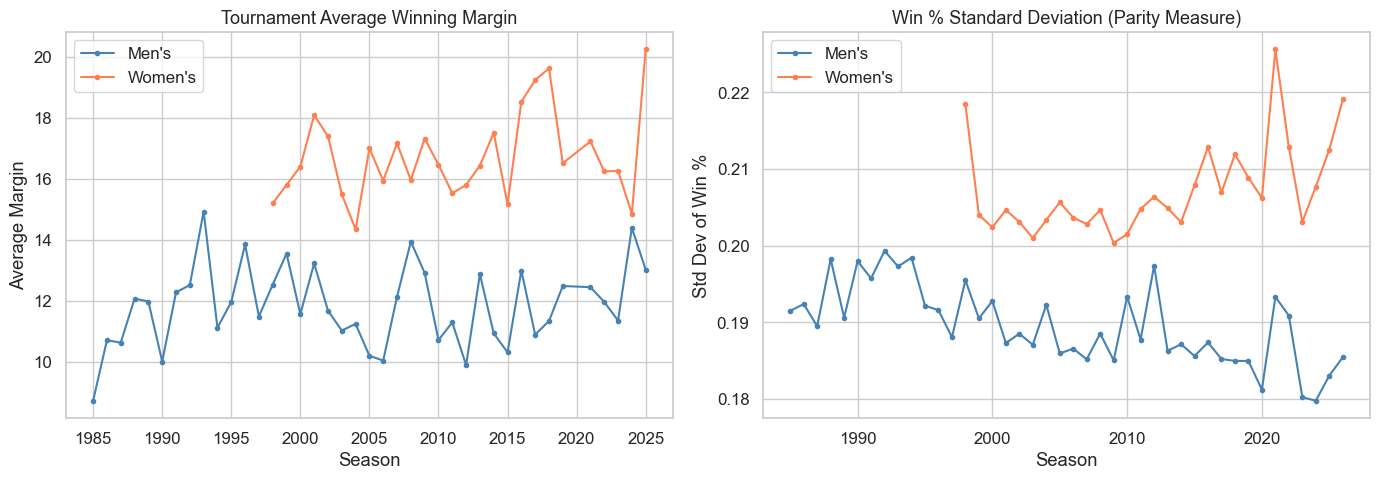

In [ ]:
# Tournament competitiveness over time
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Average margin in tournament
for df, label, color in [(m_tourney_compact, "Men's", 'steelblue'), 
                          (w_tourney_compact, "Women's", 'coral')]:
    margin = df.groupby('Season').apply(lambda x: (x['WScore'] - x['LScore']).mean())
    axes[0].plot(margin.index, margin.values, marker='o', markersize=3, label=label, color=color)

axes[0].set_title('Tournament Average Winning Margin', fontsize=13)
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Average Margin')
axes[0].legend()

# Win % variance in regular season (parity measure)
for ts, label, color in [(m_team_stats, "Men's", 'steelblue'), (w_team_stats, "Women's", 'coral')]:
    parity = ts.groupby('Season')['WinPct'].std()
    axes[1].plot(parity.index, parity.values, marker='o', markersize=3, label=label, color=color)

axes[1].set_title('Win % Standard Deviation (Parity Measure)', fontsize=13)
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Std Dev of Win %')
axes[1].legend()

plt.tight_layout()
plt.show()

<a id='12'></a>
## 12. Feature Engineering Ideas & Summary

### Key Findings Summary

**Scoring:**
- Men's games score higher than women's (~140 vs ~125 total points per game)
- Tournament games are tighter than regular season
- Home court advantage is significant (~60%+ home win rate)

**Seeds:**
- Seeds are highly predictive, especially for large seed differentials
- 1-seeds dominate championships (60%+ in men's, even more in women's)
- Women's tournament is more "chalk" (fewer upsets) than men's
- 8 vs 9 matchup is nearly a coin flip

**Box Scores:**
- FG% and eFG% differentials are the strongest correlates with winning
- Turnovers and rebounds are critical differentiators
- 3-point shooting volume has increased dramatically over time
- Four Factors analysis confirms champions excel at shooting efficiency and turnover avoidance

**Rankings:**
- Multiple ranking systems achieve 70%+ accuracy on tournament prediction
- Composite rankings (average across systems) can rival the best individual systems
- Rank differential maps cleanly to win probability (useful for calibration)

**Conferences:**
- Power conferences (ACC, Big Ten, SEC, Big 12, Big East) dominate tournament success
- Conference realignment has significantly changed the landscape

---

### Recommended Features for Modeling

**Team-Level Season Features:**
- Win percentage (overall, last N games)
- Points per game, opponent PPG, point differential
- Strength of schedule (avg opponent win %)
- Tournament experience (# prior appearances)

**Box Score Derived Features (from detailed results):**
- Four Factors: eFG%, turnover rate, offensive rebound %, free throw rate
- Shooting percentages (FG%, 3P%, FT%) and their differentials
- Assist-to-turnover ratio
- Rebounding margin

**Ranking Features (from Massey Ordinals):**
- End-of-season rank from top 5 most predictive systems
- Composite rank (average across systems)
- Rank trajectory (season improvement/decline)

**Seed Features:**
- Numeric seed (1-16)
- Seed difference between teams
- Historical seed matchup win probability (lookup table)

**Matchup Features (for each TeamA vs TeamB pair):**
- Rank differential
- Stat differentials (each box score stat)
- Conference strength differential

---

### Modeling Strategy Notes

1. **Baseline:** Seed-based probability lookup (from Section 7 heatmap)
2. **Strong baseline:** Logistic regression on rank differentials from top Massey systems
3. **Advanced:** Gradient boosting (XGBoost/LightGBM) with all features
4. **Calibration:** Platt scaling or isotonic regression to ensure well-calibrated probabilities
5. **CV Strategy:** Leave-one-season-out cross-validation
6. **Men's vs Women's:** Consider separate models or include a gender indicator feature
7. **Brier Score optimization:** Focus on calibration — well-calibrated probabilities matter more than accuracy